In [16]:
# NOTE: This file is the source for three Jupyter notebook cells.
# Copy each section into its own cell.
# =============================================================================

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports · API path · Global parameters · Fixed refractive indices ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import sys
import os
import platform
import time
import logging
from pathlib import Path
from datetime import datetime

import numpy as np
import h5py

# ─────────────────────────────────────────────────────────────────────────────
# Lumerical installation paths
# ► Set LUMERICAL_VERSION to exactly match your installation folder name.
#   Check:  C:\Program Files\Lumerical\   and read the subfolder name.
# ─────────────────────────────────────────────────────────────────────────────
LUMERICAL_VERSION = "v202"          # ← confirmed from your traceback

if platform.system() == "Windows":
    LUMERICAL_ROOT = rf"C:\Program Files\Lumerical\{LUMERICAL_VERSION}"
    LUMERICAL_API  = rf"{LUMERICAL_ROOT}\api\python"
    LUMERICAL_BIN  = rf"{LUMERICAL_ROOT}\bin"
else:
    LUMERICAL_ROOT = f"/opt/lumerical/{LUMERICAL_VERSION}"
    LUMERICAL_API  = f"{LUMERICAL_ROOT}/api/python"
    LUMERICAL_BIN  = f"{LUMERICAL_ROOT}/bin"

# ── 1. Clear any previously cached failed import ─────────────────────────────
# If lumapi was imported and failed in this kernel session, Python stores the
# broken module in sys.modules and returns the same failure on every retry.
# Removing it forces a clean re-import.
if "lumapi" in sys.modules:
    del sys.modules["lumapi"]

# ── 2. Add the API folder to sys.path ────────────────────────────────────────
if LUMERICAL_API not in sys.path:
    sys.path.insert(0, LUMERICAL_API)

# ── 3. Register the bin directory as a DLL search path ───────────────────────
# REQUIRED on Python 3.8+ (you are on 3.11).
# os.environ["PATH"] manipulation does NOT work for CDLL() from Python 3.8
# onwards — Windows changed DLL resolution to ignore PATH by default.
# os.add_dll_directory() is the correct API.
if platform.system() == "Windows":
    if hasattr(os, "add_dll_directory"):          # Python 3.8+  ← your case
        os.add_dll_directory(str(LUMERICAL_BIN))
    else:                                          # Python < 3.8 fallback
        os.environ["PATH"] = (
            str(LUMERICAL_BIN) + ";" + os.environ.get("PATH", "")
        )

# ── 4. Verify the paths exist before importing ───────────────────────────────
assert Path(LUMERICAL_API).exists(), (
    f"Lumerical API path not found:\n  {LUMERICAL_API}\n"
    f"Check LUMERICAL_VERSION = '{LUMERICAL_VERSION}'"
)
assert Path(LUMERICAL_BIN).exists(), (
    f"Lumerical bin path not found:\n  {LUMERICAL_BIN}"
)

import lumapi  # noqa — must come after all path setup above
print(f"lumapi imported successfully from:\n  {lumapi.__file__}")

# ─────────────────────────────────────────────────────────────────────────────
# Logging
# ─────────────────────────────────────────────────────────────────────────────
logging.basicConfig(
    level   = logging.INFO,
    format  = "%(asctime)s │ %(levelname)s │ %(message)s",
    datefmt = "%H:%M:%S",
)
log = logging.getLogger("SiN_FDE")

# ─────────────────────────────────────────────────────────────────────────────
# I/O  ─ directory and HDF5 output path
# ─────────────────────────────────────────────────────────────────────────────
VERSION_NAME = "LUM_SiN_STRp_400nm_wdth_sweep_V1"
PROJECT_DIR  = Path.cwd()
DATA_DIR     = PROJECT_DIR / "data_STRp_SiN_mode_analysis_LUM"
DATA_DIR.mkdir(parents=True, exist_ok=True)
HDF5_PATH    = DATA_DIR / f"{VERSION_NAME}.h5"

# ─────────────────────────────────────────────────────────────────────────────
# Waveguide geometry  (µm throughout unless stated)
#
#  Cross-section  (Y-Z plane, X = propagation direction):
#
#     ┌────────────────────────────────────────────┐
#     │        Aqueous  n = 1.33  (upper clad)     │  z >  +core_t/2
#     │     ┌────────────────────┐                 │
#     │     │       SiN          │  core_t = 0.4   │  z ∈ [-0.2, +0.2] µm
#     │     └────────────────────┘                 │
#     │        SiO₂  n = 1.4469  (lower clad)      │  z < -0.2 µm
#     └────────────────────────────────────────────┘
#              ←—— width sweep ——→
# ─────────────────────────────────────────────────────────────────────────────
CORE_THICKNESS_UM  = 0.400    # SiN core height  [µm]
N_MODES_REQUEST    = 6        # max modes to request from the FDE eigenvalue solver

# Simulation domain margins
SIM_Y_MARGIN_UM    = 2.5      # lateral cladding margin each side beyond core half-width [µm]
SIM_Z_BELOW_UM     = 2.0      # SiO₂ substrate depth below core bottom [µm]
SIM_Z_ABOVE_UM     = 2.0      # aqueous depth above core top           [µm]

# ─────────────────────────────────────────────────────────────────────────────
# Fixed refractive indices  (evaluated at 1550 nm via Sellmeier,
# held constant across the entire wavelength and width sweep)
#
#   n_SiN  = sqrt(1 + 2.9144·λ²/(λ²-0.1366²) + 0.004873/(λ²-1.6606²))
#          → 1.980780 at 1550 nm
#
#   n_SiO2 = sqrt(1 + 1.1056·λ²/(λ²-0.078²) + 2.360·λ²/(λ²-16.681²)) + 0.002
#          → 1.446940 at 1550 nm
#
#   n_aq   = 1.33   (aqueous medium, constant by definition)
# ─────────────────────────────────────────────────────────────────────────────
N_SIN_FIXED   = 1.99   # SiN  @ 1550 nm  — used for FDE index and mesh sizing
N_SIO2_FIXED  = 1.4469   # SiO₂ @ 1550 nm  — used for FDE index and guided-mode cutoff
N_UPPER_CLADDING = 1.33  # aqueous medium   — used for FDE index (constant)

# ─────────────────────────────────────────────────────────────────────────────
# Width sweep   600 nm → 1500 nm,  100 uniformly-spaced points
# ─────────────────────────────────────────────────────────────────────────────
SWEEP_WIDTHS_UM = np.linspace(0.600, 1.500, 100)    # [µm]

# ─────────────────────────────────────────────────────────────────────────────
# Wavelength sweep  :  λ₀ = 1550 nm  +  12 jumps of (10/13) nm  →  13 points
#
#   λₙ = 1550 + n × (10/13)  nm      n = 0, 1, … 12
#   λ₁₂ = 1550 + 120/13 ≈ 1559.2308 nm
# ─────────────────────────────────────────────────────────────────────────────
LAMBDA_START_NM  = 1550.0
DELTA_LAMBDA_NM  = 10.0 / 13.0          # ≈ 0.769231 nm  (exact rational step)
N_WAVELENGTHS    = 13                    # 0 … 12 inclusive
SWEEP_WL_NM  = LAMBDA_START_NM + np.arange(N_WAVELENGTHS) * DELTA_LAMBDA_NM
SWEEP_WL_UM  = SWEEP_WL_NM * 1e-3       # [µm]
SWEEP_WL_M   = SWEEP_WL_UM * 1e-6       # [m]  — Lumerical SI units

# ─────────────────────────────────────────────────────────────────────────────
# Derived domain dimensions
# ─────────────────────────────────────────────────────────────────────────────
# y: accommodate the widest core (1.5 µm) + 2 × lateral margin
SIM_Y_SPAN_UM  = SWEEP_WIDTHS_UM.max() + 2.0 * SIM_Y_MARGIN_UM      # 6.5 µm

# z: SiO₂ below  +  core  +  aqueous above
SIM_Z_SPAN_UM  = SIM_Z_BELOW_UM + CORE_THICKNESS_UM + SIM_Z_ABOVE_UM # 4.4 µm

# ─────────────────────────────────────────────────────────────────────────────
# Mesh sizing:  target ≈ λ_max / (N_SIN_FIXED × 10)
#   i.e. 10 mesh cells per wavelength inside the core material.
#   N_SIN_FIXED is used directly here — no separate approximation variable.
#
# Raise MESH_CELLS_PER_WVL to 15–20 for publication-grade neff accuracy.
# ─────────────────────────────────────────────────────────────────────────────
MESH_CELLS_PER_WVL = 10
_mesh_step_um      = SWEEP_WL_UM.max() / (N_SIN_FIXED * MESH_CELLS_PER_WVL)
MESH_CELLS_Y       = int(np.ceil(SIM_Y_SPAN_UM / _mesh_step_um))   # ≈ 83
MESH_CELLS_Z       = int(np.ceil(SIM_Z_SPAN_UM / _mesh_step_um))   # ≈ 56

# ─────────────────────────────────────────────────────────────────────────────
# Summary printout
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 62)
print("  SiN Straight Waveguide — 2D FDE Width Sweep  (Lumerical)")
print("=" * 62)
print(f"  Version      : {VERSION_NAME}")
print(f"  Widths       : {SWEEP_WIDTHS_UM[0]*1e3:.0f} → {SWEEP_WIDTHS_UM[-1]*1e3:.0f} nm  "
      f"({len(SWEEP_WIDTHS_UM)} pts)")
print(f"  Wavelengths  : {SWEEP_WL_NM[0]:.4f} → {SWEEP_WL_NM[-1]:.4f} nm  "
      f"({N_WAVELENGTHS} pts,  Δλ = 10/13 ≈ {DELTA_LAMBDA_NM:.5f} nm)")
print(f"  Core h       : {CORE_THICKNESS_UM*1e3:.0f} nm")
print(f"  n_SiN        : {N_SIN_FIXED}  (fixed @ 1550 nm)")
print(f"  n_SiO₂       : {N_SIO2_FIXED}  (fixed @ 1550 nm)  ← guided-mode cutoff")
print(f"  n_aqueous    : {N_UPPER_CLADDING}  (constant)")
print(f"  Domain       : y = {SIM_Y_SPAN_UM:.2f} µm,  z = {SIM_Z_SPAN_UM:.2f} µm")
print(f"  Mesh step    : ≈ {_mesh_step_um*1e3:.1f} nm  "
      f"({MESH_CELLS_Y} × {MESH_CELLS_Z} cells,  "
      f"≈ λ_max / (n_SiN × {MESH_CELLS_PER_WVL}))")
print(f"  Total FDE    : {len(SWEEP_WIDTHS_UM)} × {N_WAVELENGTHS} = "
      f"{len(SWEEP_WIDTHS_UM)*N_WAVELENGTHS} runs")
print(f"  HDF5 output  : {HDF5_PATH}")
print("=" * 62)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — FDE helpers  +  main sweep function                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# Helper 1 :  _init_fde_geometry
#   Clears the session, creates the FDE solver region and the three material
#   rectangles.  Called ONCE at the start; geometry is then updated in-loop
#   via setnamed() to avoid rebuilding from scratch on every width step.
#
#   Material indices are set from the fixed constants N_SIN_FIXED,
#   N_SIO2_FIXED, N_UPPER_CLADDING — no Sellmeier evaluation.
#
#   Structure override order (same default mesh-order → last added wins):
#     1st added  →  Aqueous_bg          (background, lowest priority)
#     2nd added  →  SiO2_lower_clad     (overrides Aqueous below the core)
#     3rd added  →  SiN_core            (overrides everything, highest priority)
# ─────────────────────────────────────────────────────────────────────────────
def _init_fde_geometry(
    mode,
    wavelength_m      : float,
    initial_width_m   : float,
    core_t_um         : float,
    sim_y_span_um     : float,
    sim_z_span_um     : float,
    sim_z_ctr_um      : float,
    sio2_z_ctr_um     : float,
    sio2_z_span_um    : float,
    mesh_cells_y      : int,
    mesh_cells_z      : int,
    n_modes_request   : int,
):
    """
    Creates FDE solver region + three material rectangles in a clean session.
    Indices are taken directly from the module-level constants
    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING.
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver region ────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     sim_z_ctr_um     * 1e-6)
    m.set("y span",                sim_y_span_um    * 1e-6)
    m.set("z span",                sim_z_span_um    * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", n_modes_request)
    m.set("mesh cells y",          mesh_cells_y)
    m.set("mesh cells z",          mesh_cells_z)

    # ── 1st structure : Aqueous background (full domain, lowest priority) ────
    m.addrect()
    m.set("name",    "Aqueous_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sim_z_ctr_um  * 1e-6)
    m.set("z span",  sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_UPPER_CLADDING)             # 1.33, constant

    # ── 2nd structure : SiO₂ lower-cladding slab ─────────────────────────────
    # Spans full y, from domain bottom up to the core bottom (z = -core_t/2)
    m.addrect()
    m.set("name",    "SiO2_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sio2_z_ctr_um  * 1e-6)
    m.set("z span",  sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)                 # 1.4469, fixed

    # ── 3rd structure : SiN waveguide core (highest priority) ────────────────
    # y span is updated in the inner width loop; all other dims are fixed.
    m.addrect()
    m.set("name",    "SiN_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", initial_width_m)
    m.set("z",       0.0);  m.set("z span", core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)                  # 1.9808, fixed


# ─────────────────────────────────────────────────────────────────────────────
# Helper 2 :  _extract_mode_results
#   After findmodes() reads neff (complex), TE polarization fraction, and
#   counts guided modes.
#
#   Guided criterion:  Re(neff) > N_SIO2_FIXED
#   This is the physically correct cutoff for an asymmetric waveguide whose
#   highest-index cladding is SiO₂.  Radiation modes discretised by the
#   finite simulation domain have neff < N_SIO2_FIXED and are filtered out.
#
#   Returns arrays of shape (n_modes_request,) — NaN where a mode was not found.
# ─────────────────────────────────────────────────────────────────────────────
def _extract_mode_results(mode, n_modes_request: int):
    """
    Extract neff (complex), TE fraction, and guided-mode count from the FDE
    result after findmodes().

    Uses N_SIO2_FIXED (module-level constant) as the guided-mode cutoff.

    Returns
    -------
    neff_real : np.ndarray  (n_modes_request,)   Re(neff), NaN if not found
    neff_imag : np.ndarray  (n_modes_request,)   Im(neff)
    te_frac   : np.ndarray  (n_modes_request,)   TE polarization fraction
    n_guided  : int                               count of guided modes
    """
    neff_real = np.full(n_modes_request, np.nan, dtype=np.float64)
    neff_imag = np.full(n_modes_request, np.nan, dtype=np.float64)
    te_frac   = np.full(n_modes_request, np.nan, dtype=np.float64)
    n_guided  = 0

    for m_i in range(1, n_modes_request + 1):
        mode_grp = f"FDE::data::mode{m_i}"
        try:
            raw_neff = mode.getdata(mode_grp, "neff")
            raw_te   = mode.getdata(mode_grp, "TE polarization fraction")
        except Exception:
            break   # no more modes available — stop

        # Normalise to Python scalar regardless of array shape returned
        neff_c = complex(np.asarray(raw_neff).flat[0])
        te_v   = float(np.asarray(raw_te).flat[0])

        neff_real[m_i - 1] = neff_c.real
        neff_imag[m_i - 1] = neff_c.imag
        te_frac  [m_i - 1] = te_v

        # Guided-mode test: Re(neff) must exceed the highest cladding index
        if neff_c.real > N_SIO2_FIXED:
            n_guided += 1

    return neff_real, neff_imag, te_frac, n_guided


# ─────────────────────────────────────────────────────────────────────────────
# Helper 3 :  _init_hdf5
#   Creates a fresh HDF5 file with pre-allocated datasets and full metadata.
#   Uses chunked storage so incremental slice-writes are efficient.
# ─────────────────────────────────────────────────────────────────────────────
def _init_hdf5(
    path            : Path,
    n_w             : int,
    n_wl            : int,
    n_modes         : int,
    sweep_widths_um : np.ndarray,
    sweep_wl_um     : np.ndarray,
    metadata        : dict,
):
    with h5py.File(path, "w") as f:
        # — metadata group ————————————————————————————————————————————————————
        md = f.create_group("metadata")
        md.create_dataset("sweep_widths_um",      data=sweep_widths_um)
        md.create_dataset("sweep_wavelengths_nm", data=sweep_wl_um * 1e3)
        md.create_dataset("sweep_wavelengths_um", data=sweep_wl_um)
        for k, v in metadata.items():
            md.attrs[k] = v
        md.attrs["timestamp_start"] = datetime.now().isoformat()

        # — result datasets  (NaN-initialised, chunked per width row) ─────────
        chunk_shape = (1, n_wl, n_modes)
        nan3d = np.full((n_w, n_wl, n_modes), np.nan, dtype=np.float64)
        rg = f.create_group("results")
        rg.create_dataset("neff_real", data=nan3d, chunks=chunk_shape)
        rg.create_dataset("neff_imag", data=nan3d, chunks=chunk_shape)
        rg.create_dataset("te_frac",   data=nan3d, chunks=chunk_shape)
        rg.create_dataset("n_guided",
                          data=np.zeros((n_w, n_wl), dtype=np.int32),
                          chunks=(1, n_wl))

        # — progress flag ─────────────────────────────────────────────────────
        f.create_group("flags").create_dataset(
            "computed",
            data=np.zeros((n_w, n_wl), dtype=bool),
            chunks=(1, n_wl),
        )


# ─────────────────────────────────────────────────────────────────────────────
# Main function :  run_width_sweep_fde
# ─────────────────────────────────────────────────────────────────────────────
def run_width_sweep_fde(
    sweep_widths_um    = SWEEP_WIDTHS_UM,
    sweep_wl_um        = SWEEP_WL_UM,
    core_thickness_um  = CORE_THICKNESS_UM,
    n_modes_request    = N_MODES_REQUEST,
    sim_y_span_um      = SIM_Y_SPAN_UM,
    sim_z_below_um     = SIM_Z_BELOW_UM,
    sim_z_above_um     = SIM_Z_ABOVE_UM,
    mesh_cells_y       = MESH_CELLS_Y,
    mesh_cells_z       = MESH_CELLS_Z,
    hdf5_path          = HDF5_PATH,
    version_name       = VERSION_NAME,
    hide_gui           = False,           # set True for headless / HPC runs
):
    """
    2-D FDE width sweep for a straight SiN waveguide on SiO₂ with aqueous top
    cladding, using Lumerical MODE Solutions via the Python lumapi.

    Material indices are fixed constants (N_SIN_FIXED, N_SIO2_FIXED,
    N_UPPER_CLADDING) — no Sellmeier evaluation at any point.

    Sweep axes
    ----------
    - Inner  :  SiN core y-span  (600 nm → 1500 nm,  100 pts)
    - Outer  :  wavelength        (1550.0 nm → 1559.23 nm,  13 pts)

    At each (width, λ) point the function
      1. Updates the FDE solver wavelength and the core y-span.
      2. Runs mesh  →  findmodes()  →  extracts neff + TE fraction.
      3. Counts guided modes  (Re(neff) > N_SIO2_FIXED).
      4. Writes results to HDF5 immediately and flushes — safe to interrupt.

    Re-running skips already-computed points automatically (cache check via
    flags/computed dataset in HDF5).

    Returns
    -------
    dict with keys:
        neff_real       np.ndarray  [n_widths, n_wl, n_modes_request]
        neff_imag       np.ndarray  [n_widths, n_wl, n_modes_request]
        te_frac         np.ndarray  [n_widths, n_wl, n_modes_request]
        n_guided        np.ndarray  [n_widths, n_wl]
        computed        np.ndarray  [n_widths, n_wl]  bool
        sweep_widths_um np.ndarray  [n_widths]  µm
        sweep_wl_nm     np.ndarray  [n_wl]      nm
    """
    n_w   = len(sweep_widths_um)
    n_wl  = len(sweep_wl_um)
    n_mod = n_modes_request

    # ── Pre-compute all fixed geometry quantities ─────────────────────────────
    half_t         = core_thickness_um / 2.0
    sim_z_span_tot = sim_z_below_um + core_thickness_um + sim_z_above_um

    # Core sits at z = 0  →  SiO₂ slab spans  z ∈ [-(half_t + sim_z_below), -half_t]
    sio2_z_span = sim_z_below_um
    sio2_z_ctr  = -(half_t + sim_z_below_um / 2.0)

    # Simulation region centre (= 0 when below == above, i.e. symmetric domain)
    sim_z_ctr   = (sim_z_above_um - sim_z_below_um) / 2.0

    # ── Allocate in-memory result arrays ──────────────────────────────────────
    neff_real = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    neff_imag = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    te_frac   = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    n_guided  = np.zeros((n_w, n_wl), dtype=np.int32)
    computed  = np.zeros((n_w, n_wl), dtype=bool)

    # ── HDF5 : load cache or create new file ─────────────────────────────────
    if hdf5_path.exists():
        log.info(f"Cache found → {hdf5_path}")
        with h5py.File(hdf5_path, "r") as f:
            if "results/neff_real" in f:
                neff_real[:] = f["results/neff_real"][:]
                neff_imag[:] = f["results/neff_imag"][:]
                te_frac[:]   = f["results/te_frac"][:]
                n_guided[:]  = f["results/n_guided"][:]
                computed[:]  = f["flags/computed"][:]
        n_cached  = int(computed.sum())
        remaining = n_w * n_wl - n_cached
        log.info(f"Cached: {n_cached}/{n_w*n_wl}  |  Remaining: {remaining}")
        if remaining == 0:
            log.info("All points already computed — returning cached results.")
            return dict(
                neff_real       = neff_real,
                neff_imag       = neff_imag,
                te_frac         = te_frac,
                n_guided        = n_guided,
                computed        = computed,
                sweep_widths_um = sweep_widths_um,
                sweep_wl_nm     = sweep_wl_um * 1e3,
            )
    else:
        log.info("No cache found — initialising new HDF5 file.")
        _init_hdf5(
            path            = hdf5_path,
            n_w             = n_w,
            n_wl            = n_wl,
            n_modes         = n_mod,
            sweep_widths_um = sweep_widths_um,
            sweep_wl_um     = sweep_wl_um,
            metadata        = {
                "version_name"     : version_name,
                "core_thickness_um": core_thickness_um,
                "n_SiN_fixed"      : N_SIN_FIXED,
                "n_SiO2_fixed"     : N_SIO2_FIXED,
                "n_upper_cladding" : N_UPPER_CLADDING,
                "sim_y_span_um"    : sim_y_span_um,
                "sim_z_below_um"   : sim_z_below_um,
                "sim_z_above_um"   : sim_z_above_um,
                "mesh_cells_y"     : mesh_cells_y,
                "mesh_cells_z"     : mesh_cells_z,
                "n_modes_request"  : n_mod,
                "delta_lambda_nm"  : float(np.diff(sweep_wl_um * 1e3).mean()),
            },
        )

    # ── Open Lumerical MODE session ───────────────────────────────────────────
    log.info("Launching Lumerical MODE …")
    mode = lumapi.MODE(hide=hide_gui)

    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        # ── Build geometry once ───────────────────────────────────────────────
        # Wavelength for the initial FDE setup: first point of the sweep.
        # Derived from the function parameter sweep_wl_um — not from any global.
        _init_fde_geometry(
            mode            = mode,
            wavelength_m    = float(sweep_wl_um[0] * 1e-6),   # µm → m
            initial_width_m = float(sweep_widths_um[0] * 1e-6),
            core_t_um       = core_thickness_um,
            sim_y_span_um   = sim_y_span_um,
            sim_z_span_um   = sim_z_span_tot,
            sim_z_ctr_um    = sim_z_ctr,
            sio2_z_ctr_um   = sio2_z_ctr,
            sio2_z_span_um  = sio2_z_span,
            mesh_cells_y    = mesh_cells_y,
            mesh_cells_z    = mesh_cells_z,
            n_modes_request = n_mod,
        )
        log.info(f"Geometry initialised  ({runs_total} FDE runs remaining) …")

        # ── Keep HDF5 open for the entire sweep  (flush after each point) ─────
        with h5py.File(hdf5_path, "r+") as hf:

            # ╔══════════════════════════════════════════════════════╗
            # ║  OUTER LOOP : wavelength                            ║
            # ╚══════════════════════════════════════════════════════╝
            for wl_idx, wl_um in enumerate(sweep_wl_um):

                # Fast-skip: all widths at this λ already cached
                if computed[:, wl_idx].all():
                    continue

                # Wavelength in SI metres — derived from function parameter
                wl_m = float(wl_um * 1e-6)

                # Only the FDE solver wavelength changes per outer iteration.
                # Material indices are fixed — no setnamed index update here.
                mode.switchtolayout()
                mode.setnamed("FDE", "wavelength", wl_m)

                log.info(
                    f"─── λ[{wl_idx:2d}] = {wl_um*1e3:.4f} nm │ "
                    f"n_SiN = {N_SIN_FIXED}  n_SiO₂ = {N_SIO2_FIXED}  "
                    f"n_aq = {N_UPPER_CLADDING}  (all fixed)"
                )

                # ╔══════════════════════════════════════════════════╗
                # ║  INNER LOOP : width                             ║
                # ╚══════════════════════════════════════════════════╝
                for w_idx, w_um in enumerate(sweep_widths_um):

                    # ── Cache check ───────────────────────────────────────
                    if computed[w_idx, wl_idx]:
                        continue

                    # ── Update core width (only geometry change per step) ──
                    mode.switchtolayout()
                    mode.setnamed("SiN_core", "y span", float(w_um * 1e-6))

                    # ── Run FDE mesh  →  find modes ───────────────────────
                    try:
                        mode.run()
                        _raw_nfound = mode.findmodes()
                        n_found     = int(np.asarray(_raw_nfound).flat[0])
                    except Exception as exc:
                        log.warning(
                            f"  FDE FAILED │ w = {w_um*1e3:.1f} nm  "
                            f"λ = {wl_um*1e3:.4f} nm │ {exc}"
                        )
                        # Mark as done with NaN result to skip on re-run
                        computed[w_idx, wl_idx]             = True
                        hf["flags/computed"][w_idx, wl_idx] = True
                        hf.flush()
                        continue

                    # ── Extract and classify modes ─────────────────────────
                    # n_found is passed only for awareness; _extract_mode_results
                    # iterates up to n_modes_request and breaks on missing modes.
                    nr, ni, tf, ng = _extract_mode_results(mode, n_mod)

                    # ── Store in memory ───────────────────────────────────
                    neff_real[w_idx, wl_idx, :] = nr
                    neff_imag[w_idx, wl_idx, :] = ni
                    te_frac  [w_idx, wl_idx, :] = tf
                    n_guided [w_idx, wl_idx]     = ng
                    computed [w_idx, wl_idx]     = True

                    # ── Write to HDF5  (incremental, fault-safe) ──────────
                    hf["results/neff_real"][w_idx, wl_idx, :] = nr
                    hf["results/neff_imag"][w_idx, wl_idx, :] = ni
                    hf["results/te_frac"]  [w_idx, wl_idx, :] = tf
                    hf["results/n_guided"] [w_idx, wl_idx]    = ng
                    hf["flags/computed"]   [w_idx, wl_idx]    = True
                    hf.flush()

                    runs_done += 1

                    # ── Progress report every 10 completed runs ───────────
                    if runs_done % 10 == 0 or runs_done == runs_total:
                        elapsed = time.time() - t_start
                        rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                        eta     = (runs_total - runs_done) / rate
                        log.info(
                            f"  [{runs_done:4d}/{runs_total}]  "
                            f"w = {w_um*1e3:6.1f} nm │ "
                            f"n_guided = {ng} │ "
                            f"{rate:.1f} sim/s │ "
                            f"ETA {eta:5.0f} s"
                        )

            # ── Close-out metadata ────────────────────────────────────────
            hf["metadata"].attrs["timestamp_end"]   = datetime.now().isoformat()
            hf["metadata"].attrs["runs_completed"]  = int(computed.sum())

    finally:
        mode.close()
        log.info("Lumerical MODE session closed.")

    elapsed_total = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total = {elapsed_total:.1f} s │ "
        f"avg = {elapsed_total / max(runs_done, 1):.2f} s/sim"
    )

    return dict(
        neff_real       = neff_real,
        neff_imag       = neff_imag,
        te_frac         = te_frac,
        n_guided        = n_guided,
        computed        = computed,
        sweep_widths_um = sweep_widths_um,
        sweep_wl_nm     = sweep_wl_um * 1e3,
    )


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Execute sweep + quick sanity output                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

results = run_width_sweep_fde()

# ── Unpack for downstream cells ───────────────────────────────────────────────
neff_real       = results["neff_real"]          # [n_widths, n_wl, n_modes]
neff_imag       = results["neff_imag"]
te_frac         = results["te_frac"]
n_guided        = results["n_guided"]           # [n_widths, n_wl]
computed        = results["computed"]
sweep_widths_um = results["sweep_widths_um"]    # [100]  µm
sweep_wl_nm     = results["sweep_wl_nm"]        # [13]   nm

print("\n" + "=" * 58)
print("  Sweep complete — result summary")
print("=" * 58)
print(f"  neff_real shape  : {neff_real.shape}  (widths × λ × modes)")
print(f"  n_guided  shape  : {n_guided.shape}")
print(f"  Points computed  : {computed.sum()} / {computed.size}")
print(f"  HDF5 saved to    : {HDF5_PATH}")

print(f"\n  Guided-mode count at λ = {sweep_wl_nm[0]:.4f} nm  (first 15 widths):")
print(f"  {'Width [nm]':>10}  {'n_guided':>10}  {'neff_mode0':>12}  {'TE_frac_0':>10}")
print("  " + "-" * 46)
for i in range(min(15, len(sweep_widths_um))):
    w_nm   = sweep_widths_um[i] * 1e3
    ng     = n_guided[i, 0]
    ne0    = neff_real[i, 0, 0]
    te0    = te_frac [i, 0, 0]
    ne_str = f"{ne0:.5f}" if not np.isnan(ne0) else "   NaN  "
    te_str = f"{te0:.3f}"  if not np.isnan(te0) else "  NaN "
    print(f"  {w_nm:>10.1f}  {ng:>10}  {ne_str:>12}  {te_str:>10}")

00:18:21 │ INFO │ Cache found → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5
00:18:21 │ INFO │ Cached: 1300/1300  |  Remaining: 0
00:18:21 │ INFO │ All points already computed — returning cached results.


lumapi imported successfully from:
  C:\Program Files\Lumerical\v202\api\python\lumapi.py
  SiN Straight Waveguide — 2D FDE Width Sweep  (Lumerical)
  Version      : LUM_SiN_STRp_400nm_wdth_sweep_V1
  Widths       : 600 → 1500 nm  (100 pts)
  Wavelengths  : 1550.0000 → 1559.2308 nm  (13 pts,  Δλ = 10/13 ≈ 0.76923 nm)
  Core h       : 400 nm
  n_SiN        : 1.99  (fixed @ 1550 nm)
  n_SiO₂       : 1.4469  (fixed @ 1550 nm)  ← guided-mode cutoff
  n_aqueous    : 1.33  (constant)
  Domain       : y = 6.50 µm,  z = 4.40 µm
  Mesh step    : ≈ 78.4 nm  (83 × 57 cells,  ≈ λ_max / (n_SiN × 10))
  Total FDE    : 100 × 13 = 1300 runs
  HDF5 output  : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5

  Sweep complete — result summary
  neff_real shape  : (100, 13, 6)  (widths × λ × modes)
  n_guided  shape  : (100, 13)
  Points computed  : 1300 / 1300
  HDF5 saved to    : D:\GitHub\GDS_py_TDY_venv\Fabrication_desi

In [17]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — SiO₂ cladding sweep : new constants + extended functions         ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–3 ALREADY EXECUTED.                                       ║
# ║  All imports, sweep arrays, mesh constants, helper functions and the        ║
# ║  first-sweep result dict are live in the kernel namespace.                  ║
# ║                                                                             ║
# ║  Only two things change vs the aqueous sweep:                               ║
# ║    1. The background/upper-cladding index  (1.33 → N_SIO2_FIXED = 1.4469)  ║
# ║    2. The output HDF5 file                                                  ║
# ║                                                                             ║
# ║  Strategy: extend _init_fde_geometry and run_width_sweep_fde with one new  ║
# ║  optional parameter each (default = original value → zero behaviour        ║
# ║  change for the aqueous sweep if it is ever re-run).                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# New constants only — nothing from Cell 1 is repeated
# ─────────────────────────────────────────────────────────────────────────────
VERSION_NAME_SIO2     = "LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1"
HDF5_PATH_SIO2        = DATA_DIR / f"{VERSION_NAME_SIO2}.h5"
N_UPPER_CLADDING_SIO2 = N_SIO2_FIXED      # 1.4469 — Silica replaces aqueous

print(f"SiO₂-cladding sweep")
print(f"  version  : {VERSION_NAME_SIO2}")
print(f"  output   : {HDF5_PATH_SIO2}")
print(f"  n_upper  : {N_UPPER_CLADDING_SIO2}  (Silica, symmetric stack)")
print(f"  n_lower  : {N_SIO2_FIXED}  (SiO₂ substrate — unchanged)")
print(f"  n_core   : {N_SIN_FIXED}   (SiN core — unchanged)")
print(f"  cutoff   : Re(neff) > {N_SIO2_FIXED}  (same threshold, now symmetric)")
print()

# ─────────────────────────────────────────────────────────────────────────────
# Extended _init_fde_geometry
# ─────────────────────────────────────────────────────────────────────────────
# ONE change vs Cell-2 version:
#   parameter  n_background (default = N_UPPER_CLADDING)  replaces the
#   hardcoded  N_UPPER_CLADDING  on the Aqueous_bg rectangle.
# All other geometry, mesh and solver settings are identical.
# ─────────────────────────────────────────────────────────────────────────────
def _init_fde_geometry(
    mode,
    wavelength_m      : float,
    initial_width_m   : float,
    core_t_um         : float,
    sim_y_span_um     : float,
    sim_z_span_um     : float,
    sim_z_ctr_um      : float,
    sio2_z_ctr_um     : float,
    sio2_z_span_um    : float,
    mesh_cells_y      : int,
    mesh_cells_z      : int,
    n_modes_request   : int,
    n_background      = N_UPPER_CLADDING,  # ← NEW: upper/lateral cladding index
                                           #   default keeps aqueous behaviour
):
    """
    Creates FDE solver region + three material rectangles in a clean session.

    n_background sets the index of the Aqueous_bg rectangle (upper and lateral
    cladding).  Defaults to N_UPPER_CLADDING (1.33, aqueous) so the original
    call in run_width_sweep_fde remains valid without any argument change.
    Pass N_SIO2_FIXED (1.4469) for the symmetric SiO₂-cladding sweep.

    N_SIN_FIXED and N_SIO2_FIXED (core and lower cladding) are always taken
    from module-level constants — they never change between sweeps.
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver region ────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     sim_z_ctr_um     * 1e-6)
    m.set("y span",                sim_y_span_um    * 1e-6)
    m.set("z span",                sim_z_span_um    * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", n_modes_request)
    m.set("mesh cells y",          mesh_cells_y)
    m.set("mesh cells z",          mesh_cells_z)

    # ── 1st structure : background (full domain, lowest priority) ─────────────
    # Name kept as "Aqueous_bg" for consistency; index is n_background.
    m.addrect()
    m.set("name",    "Aqueous_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sim_z_ctr_um  * 1e-6)
    m.set("z span",  sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    n_background)                  # ← ONLY line changed

    # ── 2nd structure : SiO₂ lower-cladding slab ─────────────────────────────
    m.addrect()
    m.set("name",    "SiO2_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sio2_z_ctr_um  * 1e-6)
    m.set("z span",  sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)

    # ── 3rd structure : SiN waveguide core (highest priority) ────────────────
    m.addrect()
    m.set("name",    "SiN_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", initial_width_m)
    m.set("z",       0.0);  m.set("z span", core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)


# ─────────────────────────────────────────────────────────────────────────────
# Extended run_width_sweep_fde
# ─────────────────────────────────────────────────────────────────────────────
# THREE changes vs Cell-2 version (all keyed on the new n_upper_cladding param):
#   1. parameter  n_upper_cladding  (default = N_UPPER_CLADDING)  added to sig
#   2. metadata dict key  "n_upper_cladding"  uses the parameter, not the const
#   3. _init_fde_geometry call passes  n_background = n_upper_cladding
#   4. log.info message shows n_upper_cladding instead of the hardcoded const
# ─────────────────────────────────────────────────────────────────────────────
def run_width_sweep_fde(
    sweep_widths_um    = SWEEP_WIDTHS_UM,
    sweep_wl_um        = SWEEP_WL_UM,
    core_thickness_um  = CORE_THICKNESS_UM,
    n_modes_request    = N_MODES_REQUEST,
    sim_y_span_um      = SIM_Y_SPAN_UM,
    sim_z_below_um     = SIM_Z_BELOW_UM,
    sim_z_above_um     = SIM_Z_ABOVE_UM,
    mesh_cells_y       = MESH_CELLS_Y,
    mesh_cells_z       = MESH_CELLS_Z,
    hdf5_path          = HDF5_PATH,
    version_name       = VERSION_NAME,
    hide_gui           = False,
    n_upper_cladding   = N_UPPER_CLADDING,  # ← NEW: default = aqueous (1.33)
):
    """
    2-D FDE width sweep for a straight SiN waveguide.

    n_upper_cladding controls the lateral and upper background index:
      - N_UPPER_CLADDING (1.33)  →  aqueous cladding  [original behaviour]
      - N_SIO2_FIXED     (1.4469) →  symmetric SiO₂ stack

    All other parameters, data structures, caching and HDF5 logic are
    identical to the original Cell-2 version.
    """
    n_w   = len(sweep_widths_um)
    n_wl  = len(sweep_wl_um)
    n_mod = n_modes_request

    # ── Pre-compute fixed geometry quantities ─────────────────────────────────
    half_t         = core_thickness_um / 2.0
    sim_z_span_tot = sim_z_below_um + core_thickness_um + sim_z_above_um
    sio2_z_span    = sim_z_below_um
    sio2_z_ctr     = -(half_t + sim_z_below_um / 2.0)
    sim_z_ctr      = (sim_z_above_um - sim_z_below_um) / 2.0

    # ── Allocate in-memory result arrays ──────────────────────────────────────
    neff_real = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    neff_imag = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    te_frac   = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    n_guided  = np.zeros((n_w, n_wl), dtype=np.int32)
    computed  = np.zeros((n_w, n_wl), dtype=bool)

    # ── HDF5 : load cache or create new file ─────────────────────────────────
    if hdf5_path.exists():
        log.info(f"Cache found → {hdf5_path}")
        with h5py.File(hdf5_path, "r") as f:
            if "results/neff_real" in f:
                neff_real[:] = f["results/neff_real"][:]
                neff_imag[:] = f["results/neff_imag"][:]
                te_frac[:]   = f["results/te_frac"][:]
                n_guided[:]  = f["results/n_guided"][:]
                computed[:]  = f["flags/computed"][:]
        n_cached  = int(computed.sum())
        remaining = n_w * n_wl - n_cached
        log.info(f"Cached: {n_cached}/{n_w*n_wl}  |  Remaining: {remaining}")
        if remaining == 0:
            log.info("All points already computed — returning cached results.")
            return dict(
                neff_real       = neff_real,
                neff_imag       = neff_imag,
                te_frac         = te_frac,
                n_guided        = n_guided,
                computed        = computed,
                sweep_widths_um = sweep_widths_um,
                sweep_wl_nm     = sweep_wl_um * 1e3,
            )
    else:
        log.info("No cache found — initialising new HDF5 file.")
        _init_hdf5(
            path            = hdf5_path,
            n_w             = n_w,
            n_wl            = n_wl,
            n_modes         = n_mod,
            sweep_widths_um = sweep_widths_um,
            sweep_wl_um     = sweep_wl_um,
            metadata        = {
                "version_name"     : version_name,
                "core_thickness_um": core_thickness_um,
                "n_SiN_fixed"      : N_SIN_FIXED,
                "n_SiO2_fixed"     : N_SIO2_FIXED,
                "n_upper_cladding" : n_upper_cladding,   # ← CHANGE 1: param, not const
                "sim_y_span_um"    : sim_y_span_um,
                "sim_z_below_um"   : sim_z_below_um,
                "sim_z_above_um"   : sim_z_above_um,
                "mesh_cells_y"     : mesh_cells_y,
                "mesh_cells_z"     : mesh_cells_z,
                "n_modes_request"  : n_mod,
                "delta_lambda_nm"  : float(np.diff(sweep_wl_um * 1e3).mean()),
            },
        )

    # ── Open Lumerical MODE session ───────────────────────────────────────────
    log.info("Launching Lumerical MODE …")
    mode = lumapi.MODE(hide=hide_gui)

    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        # ── Build geometry once ───────────────────────────────────────────────
        _init_fde_geometry(
            mode            = mode,
            wavelength_m    = float(sweep_wl_um[0] * 1e-6),
            initial_width_m = float(sweep_widths_um[0] * 1e-6),
            core_t_um       = core_thickness_um,
            sim_y_span_um   = sim_y_span_um,
            sim_z_span_um   = sim_z_span_tot,
            sim_z_ctr_um    = sim_z_ctr,
            sio2_z_ctr_um   = sio2_z_ctr,
            sio2_z_span_um  = sio2_z_span,
            mesh_cells_y    = mesh_cells_y,
            mesh_cells_z    = mesh_cells_z,
            n_modes_request = n_mod,
            n_background    = n_upper_cladding,          # ← CHANGE 2: forwarded
        )
        log.info(f"Geometry initialised  ({runs_total} FDE runs remaining) …")

        with h5py.File(hdf5_path, "r+") as hf:

            # ╔══════════════════════════════════════════════════════╗
            # ║  OUTER LOOP : wavelength                            ║
            # ╚══════════════════════════════════════════════════════╝
            for wl_idx, wl_um in enumerate(sweep_wl_um):

                if computed[:, wl_idx].all():
                    continue

                wl_m = float(wl_um * 1e-6)

                mode.switchtolayout()
                mode.setnamed("FDE", "wavelength", wl_m)

                log.info(
                    f"─── λ[{wl_idx:2d}] = {wl_um*1e3:.4f} nm │ "
                    f"n_SiN = {N_SIN_FIXED}  "
                    f"n_lower = {N_SIO2_FIXED}  "
                    f"n_upper = {n_upper_cladding}  "    # ← CHANGE 3: param
                    f"(all fixed)"
                )

                # ╔══════════════════════════════════════════════════╗
                # ║  INNER LOOP : width                             ║
                # ╚══════════════════════════════════════════════════╝
                for w_idx, w_um in enumerate(sweep_widths_um):

                    if computed[w_idx, wl_idx]:
                        continue

                    mode.switchtolayout()
                    mode.setnamed("SiN_core", "y span", float(w_um * 1e-6))

                    try:
                        mode.run()
                        _raw_nfound = mode.findmodes()
                        n_found     = int(np.asarray(_raw_nfound).flat[0])
                    except Exception as exc:
                        log.warning(
                            f"  FDE FAILED │ w = {w_um*1e3:.1f} nm  "
                            f"λ = {wl_um*1e3:.4f} nm │ {exc}"
                        )
                        computed[w_idx, wl_idx]             = True
                        hf["flags/computed"][w_idx, wl_idx] = True
                        hf.flush()
                        continue

                    nr, ni, tf, ng = _extract_mode_results(mode, n_mod)

                    neff_real[w_idx, wl_idx, :] = nr
                    neff_imag[w_idx, wl_idx, :] = ni
                    te_frac  [w_idx, wl_idx, :] = tf
                    n_guided [w_idx, wl_idx]     = ng
                    computed [w_idx, wl_idx]     = True

                    hf["results/neff_real"][w_idx, wl_idx, :] = nr
                    hf["results/neff_imag"][w_idx, wl_idx, :] = ni
                    hf["results/te_frac"]  [w_idx, wl_idx, :] = tf
                    hf["results/n_guided"] [w_idx, wl_idx]    = ng
                    hf["flags/computed"]   [w_idx, wl_idx]    = True
                    hf.flush()

                    runs_done += 1

                    if runs_done % 10 == 0 or runs_done == runs_total:
                        elapsed = time.time() - t_start
                        rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                        eta     = (runs_total - runs_done) / rate
                        log.info(
                            f"  [{runs_done:4d}/{runs_total}]  "
                            f"w = {w_um*1e3:6.1f} nm │ "
                            f"n_guided = {ng} │ "
                            f"{rate:.1f} sim/s │ "
                            f"ETA {eta:5.0f} s"
                        )

            hf["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
            hf["metadata"].attrs["runs_completed"] = int(computed.sum())

    finally:
        mode.close()
        log.info("Lumerical MODE session closed.")

    elapsed_total = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total = {elapsed_total:.1f} s │ "
        f"avg = {elapsed_total / max(runs_done, 1):.2f} s/sim"
    )

    return dict(
        neff_real       = neff_real,
        neff_imag       = neff_imag,
        te_frac         = te_frac,
        n_guided        = n_guided,
        computed        = computed,
        sweep_widths_um = sweep_widths_um,
        sweep_wl_nm     = sweep_wl_um * 1e3,
    )


print("Functions _init_fde_geometry and run_width_sweep_fde updated in namespace.")
print("Original aqueous sweep is unaffected (n_upper_cladding defaults to N_UPPER_CLADDING).")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Execute SiO₂ cladding sweep                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Only three arguments differ from the aqueous sweep defaults:
#   n_upper_cladding → N_UPPER_CLADDING_SIO2  (the material change)
#   hdf5_path        → HDF5_PATH_SIO2          (separate output file)
#   version_name     → VERSION_NAME_SIO2        (separate metadata label)
# All sweep arrays, mesh, geometry and solver settings are inherited.

print("=" * 62)
print("  SiN Straight Waveguide — SiO₂ symmetric cladding sweep")
print("=" * 62)
print(f"  Stack:  SiO₂ / SiN / SiO₂  (fully symmetric)")
print(f"  n_upper = n_lower = {N_UPPER_CLADDING_SIO2}  (Silica)")
print(f"  Widths  : {SWEEP_WIDTHS_UM[0]*1e3:.0f} → {SWEEP_WIDTHS_UM[-1]*1e3:.0f} nm  "
      f"({len(SWEEP_WIDTHS_UM)} pts)  — inherited")
print(f"  λ range : {SWEEP_WL_NM[0]:.4f} → {SWEEP_WL_NM[-1]:.4f} nm  "
      f"({N_WAVELENGTHS} pts)  — inherited")
print(f"  Output  : {HDF5_PATH_SIO2}")
print("=" * 62)

results_sio2 = run_width_sweep_fde(
    n_upper_cladding = N_UPPER_CLADDING_SIO2,
    hdf5_path        = HDF5_PATH_SIO2,
    version_name     = VERSION_NAME_SIO2,
)

# ── Unpack into clearly namespaced variables for downstream cells ─────────────
neff_real_sio2       = results_sio2["neff_real"]       # [n_widths, n_wl, n_modes]
neff_imag_sio2       = results_sio2["neff_imag"]
te_frac_sio2         = results_sio2["te_frac"]
n_guided_sio2        = results_sio2["n_guided"]        # [n_widths, n_wl]
computed_sio2        = results_sio2["computed"]
# sweep_widths_um and sweep_wl_nm are identical to the aqueous sweep —
# no new variable needed; downstream cells reference the originals.

print("\n" + "=" * 58)
print("  SiO₂ cladding sweep — result summary")
print("=" * 58)
print(f"  neff_real shape  : {neff_real_sio2.shape}  (widths × λ × modes)")
print(f"  n_guided  shape  : {n_guided_sio2.shape}")
print(f"  Points computed  : {computed_sio2.sum()} / {computed_sio2.size}")
print(f"  HDF5 saved to    : {HDF5_PATH_SIO2}")

print(f"\n  Guided-mode count at λ = {sweep_wl_nm[0]:.4f} nm  (first 15 widths):")
print(f"  {'Width [nm]':>10}  {'n_guided':>10}  {'neff_mode0':>12}  {'TE_frac_0':>10}")
print("  " + "-" * 46)
for i in range(min(15, len(sweep_widths_um))):
    w_nm   = sweep_widths_um[i] * 1e3
    ng     = n_guided_sio2[i, 0]
    ne0    = neff_real_sio2[i, 0, 0]
    te0    = te_frac_sio2  [i, 0, 0]
    ne_str = f"{ne0:.5f}" if not np.isnan(ne0) else "   NaN  "
    te_str = f"{te0:.3f}"  if not np.isnan(te0) else "  NaN "
    print(f"  {w_nm:>10.1f}  {ng:>10}  {ne_str:>12}  {te_str:>10}")

00:18:21 │ INFO │ Cache found → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5
00:18:21 │ INFO │ Cached: 1300/1300  |  Remaining: 0
00:18:21 │ INFO │ All points already computed — returning cached results.


SiO₂-cladding sweep
  version  : LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1
  output   : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5
  n_upper  : 1.4469  (Silica, symmetric stack)
  n_lower  : 1.4469  (SiO₂ substrate — unchanged)
  n_core   : 1.99   (SiN core — unchanged)
  cutoff   : Re(neff) > 1.4469  (same threshold, now symmetric)

Functions _init_fde_geometry and run_width_sweep_fde updated in namespace.
Original aqueous sweep is unaffected (n_upper_cladding defaults to N_UPPER_CLADDING).
  SiN Straight Waveguide — SiO₂ symmetric cladding sweep
  Stack:  SiO₂ / SiN / SiO₂  (fully symmetric)
  n_upper = n_lower = 1.4469  (Silica)
  Widths  : 600 → 1500 nm  (100 pts)  — inherited
  λ range : 1550.0000 → 1559.2308 nm  (13 pts)  — inherited
  Output  : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5

  Post-processing summary — polarization-resolved mode analysis
  Width : 600 → 1500 nm  (100 pts)
  λ     : 1550.0000 → 1559.2308 nm  (13 pts,  Δλ = 10/13 nm)

  Aqueous  (n_upper = 1.33)
    TE  max modes = 2  │  MM cutoff ≈ 1309 nm
    TM  max modes = 1  │  single-mode across full sweep

  Silica   (n_upper = 1.4469)
    TE  max modes = 2  │  MM cutoff ≈ 1100 nm
    TM  max modes = 2  │  MM cutoff ≈ 1236 nm

──────────────────────────────────────────────────────────────
  Plotting: Aqueous cladding
──────────────────────────────────────────────────────────────
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_modal_analysis_aqueous.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_modal_analysis_aqueous.pdf


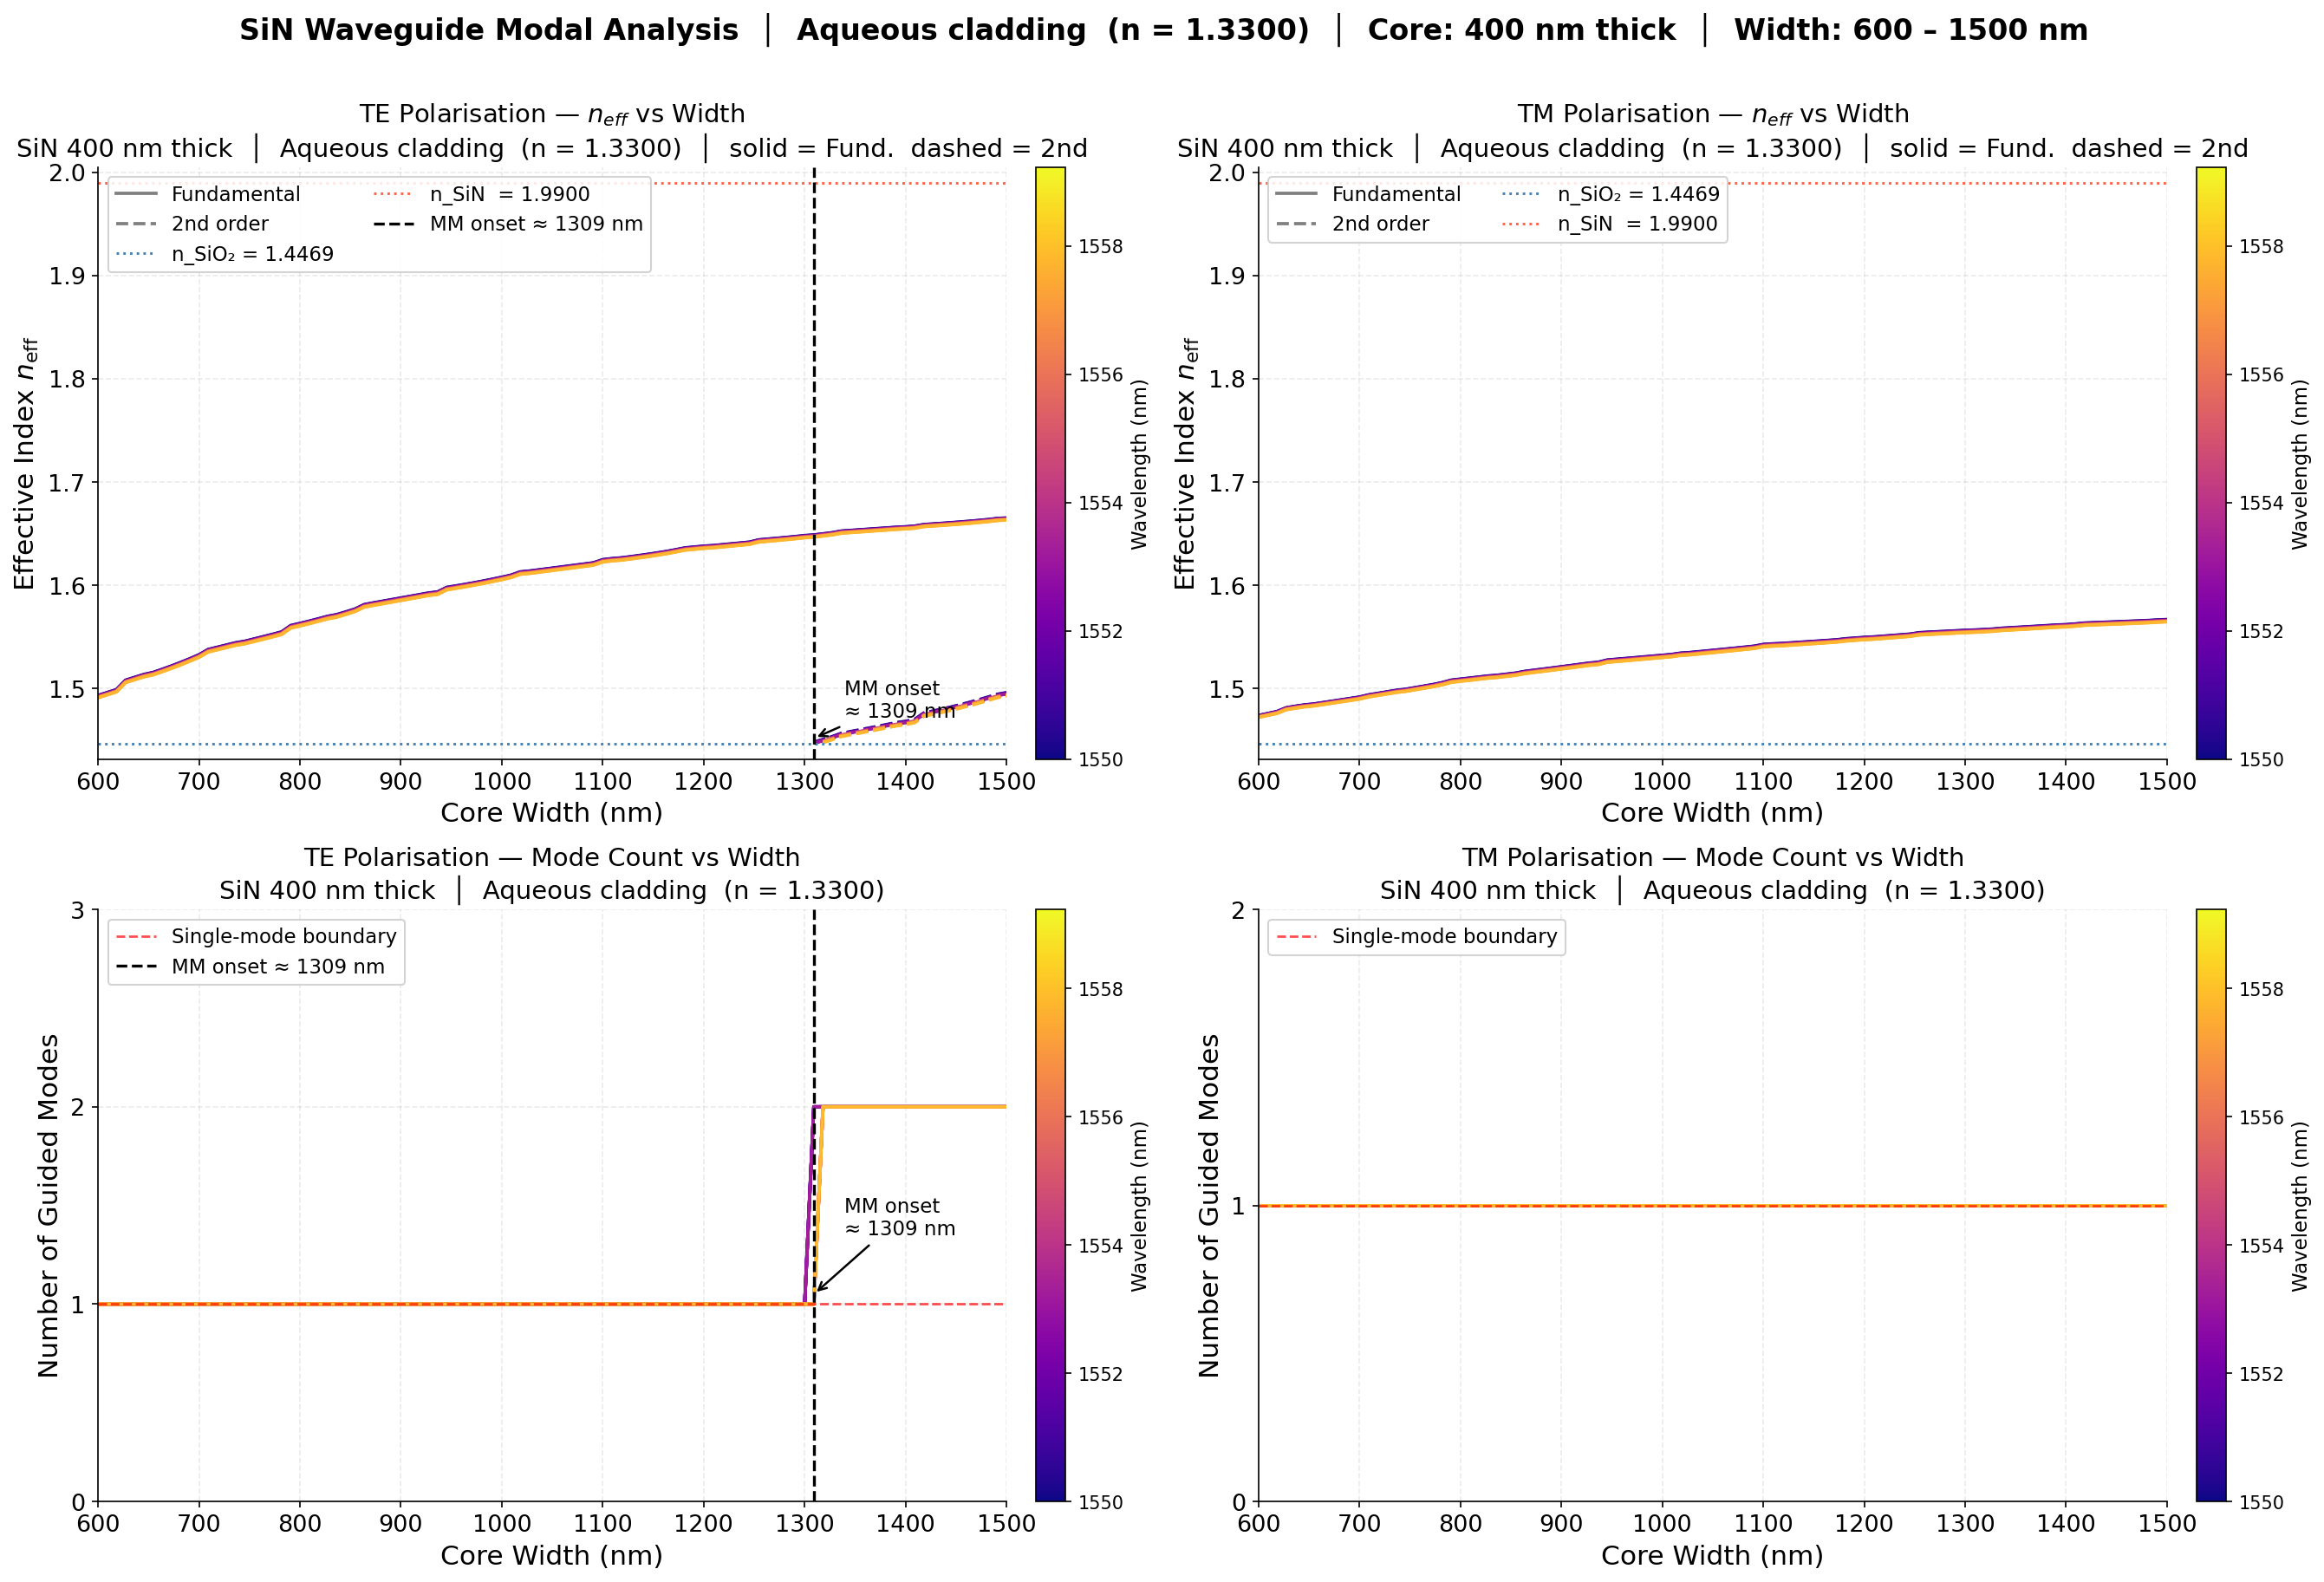


──────────────────────────────────────────────────────────────
  Plotting: Silica cladding
──────────────────────────────────────────────────────────────
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_modal_analysis_sio2clad.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_modal_analysis_sio2clad.pdf


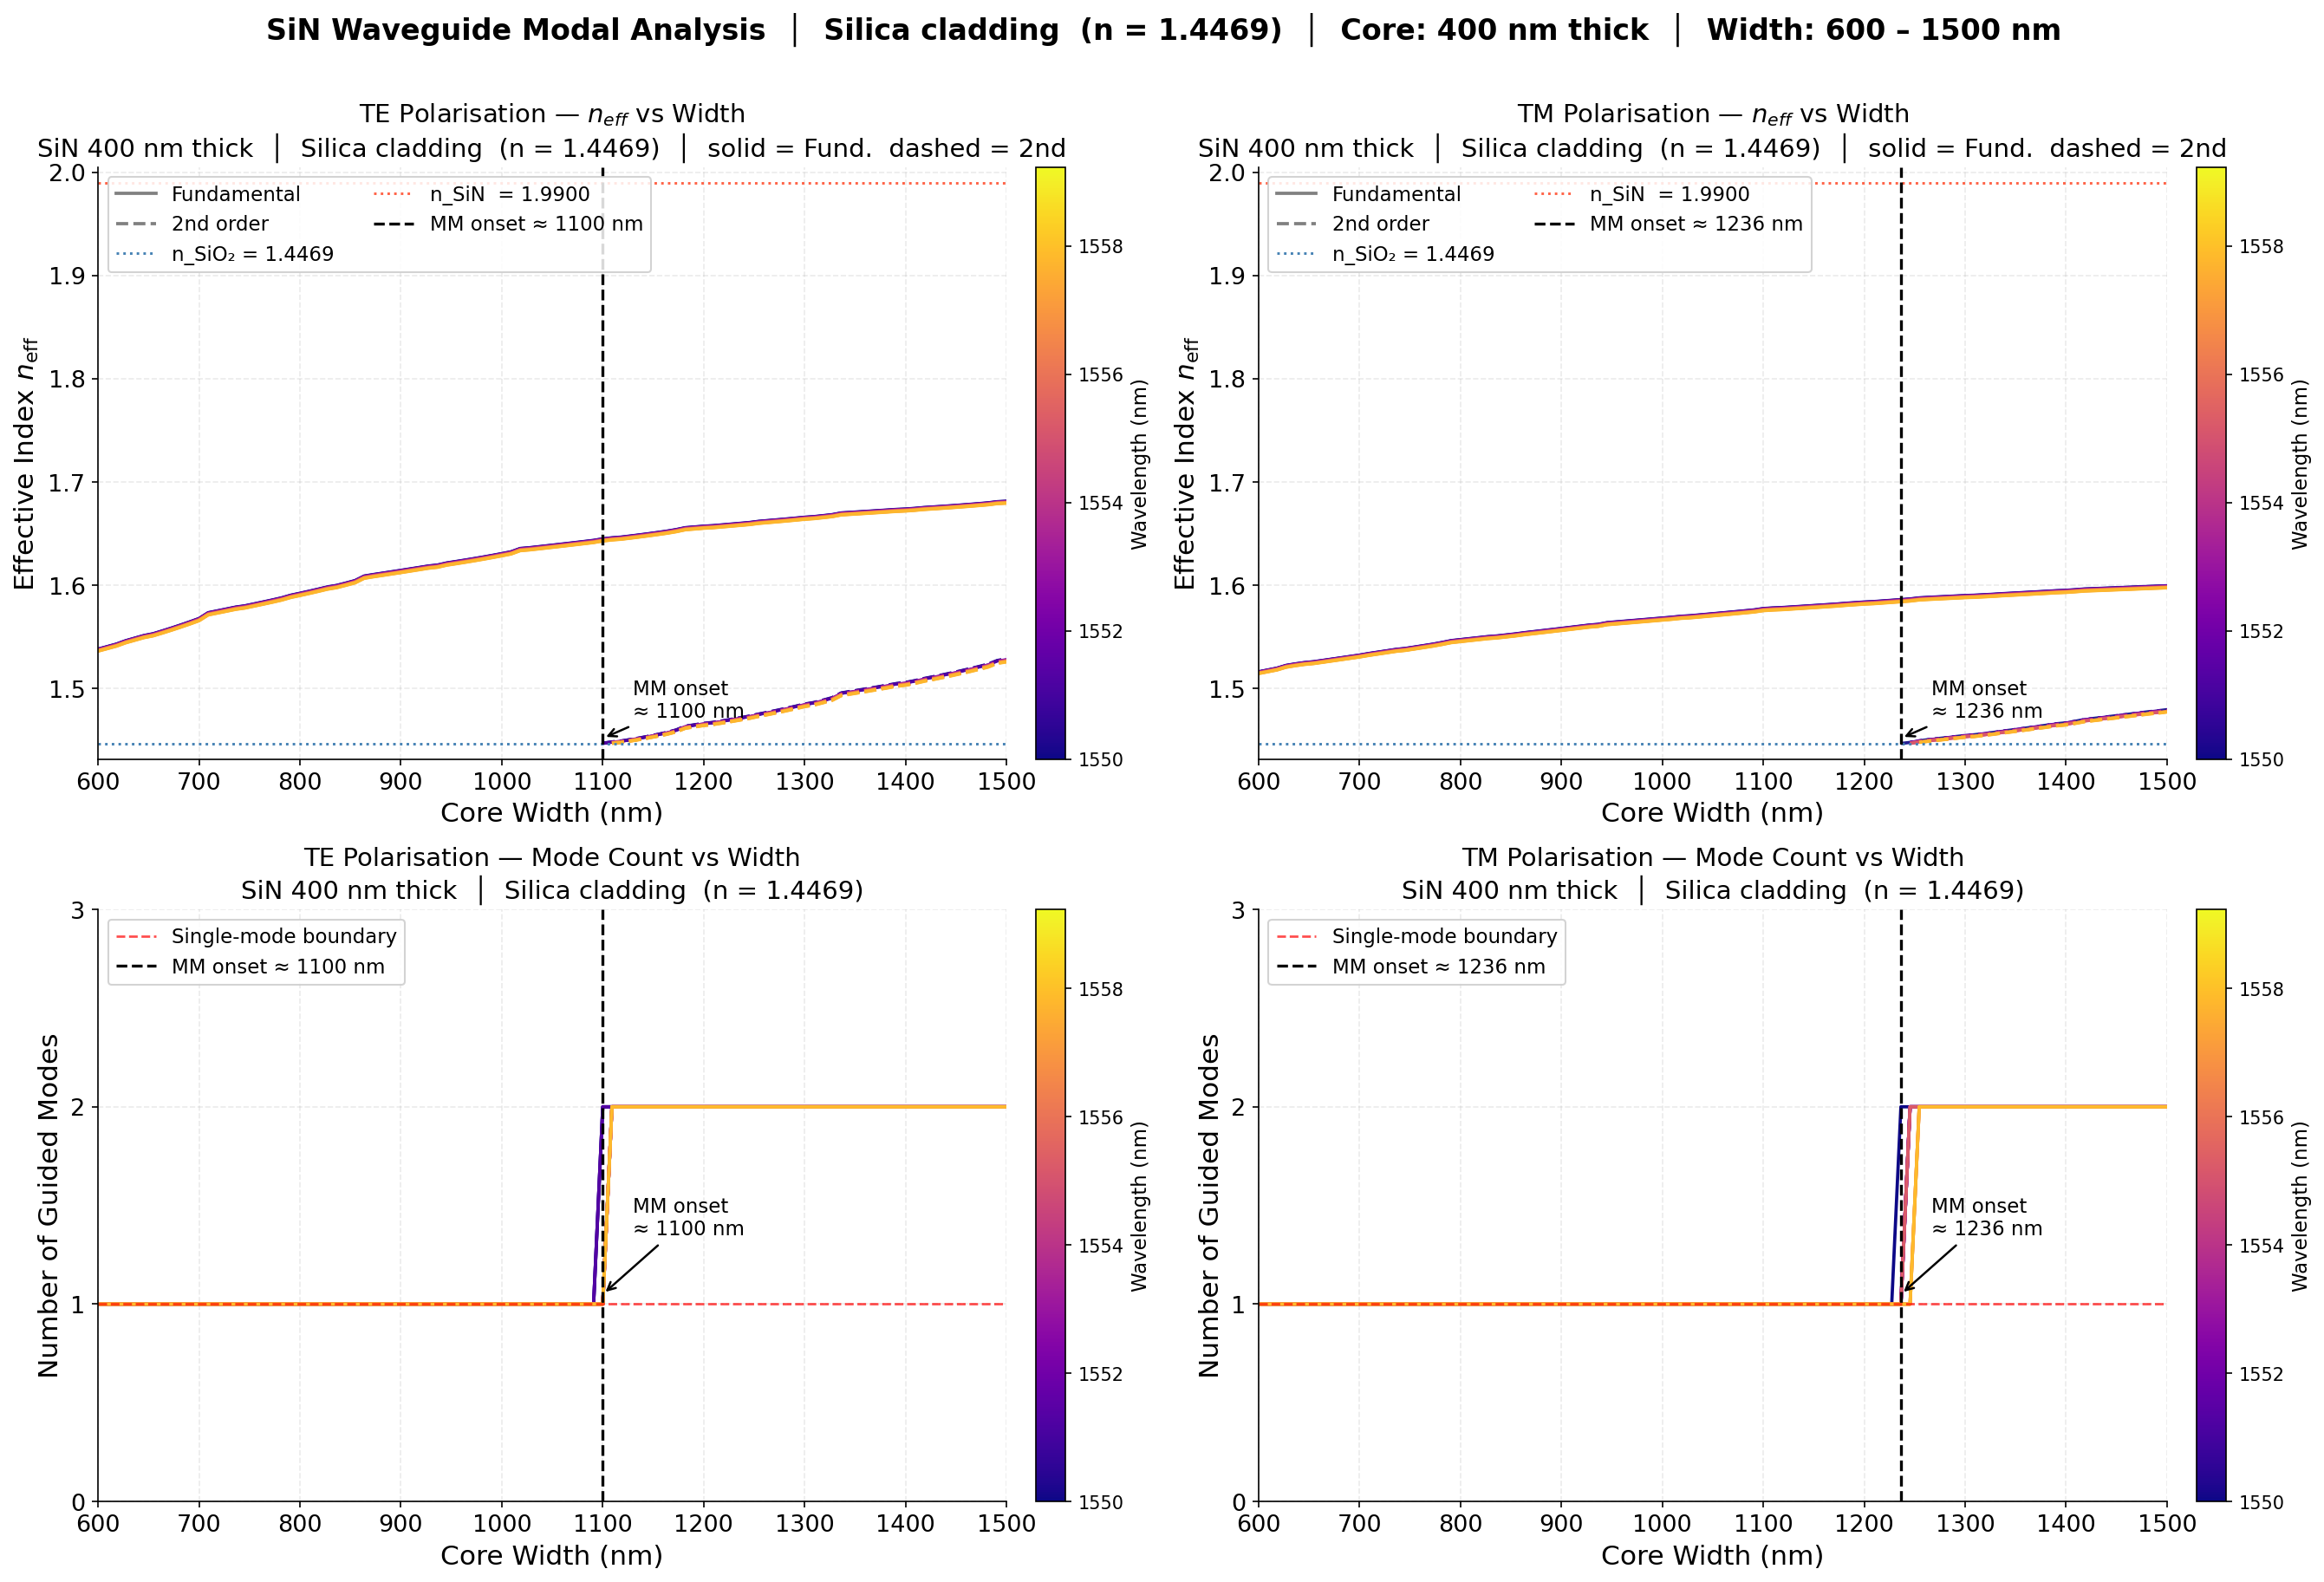

In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Post-processing: TE/TM extraction for both cladding sweeps      ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–5 ALREADY EXECUTED.                                       ║
# ║  Reuses without redefining:                                                 ║
# ║    SWEEP_WIDTHS_UM, SWEEP_WL_NM, N_SIN_FIXED, N_SIO2_FIXED,               ║
# ║    N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2, CORE_THICKNESS_UM,            ║
# ║    DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2,                              ║
# ║    neff_real, te_frac, neff_real_sio2, te_frac_sio2,                      ║
# ║    sweep_widths_um, sweep_wl_nm                                            ║
# ║                                                                             ║
# ║  New in this cell:                                                          ║
# ║    matplotlib imports, plotting style constants,                            ║
# ║    extract_pol_data(), find_mm_cutoff_nm(),                                ║
# ║    pol_aq / pol_sio2 dicts                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────
# Plotting style constants  ─ consistent with Tidy3D notebook
# ─────────────────────────────────────────────────────────────────────────────
TE_THRESHOLD    = 0.5               # te_frac > threshold → TE, else TM
MAX_POL_MODES   = 2                 # track up to 2 modes per polarization
PLASMA_RANGE    = (0.0, 0.85)       # crop plasma to avoid bright yellow tip
LINESTYLES      = ['-', '--']       # fund. = solid, 2nd order = dashed
FIG_SIZE_2X2    = (18, 12)
FONT_SUPTITLE   = 16
FONT_TITLE      = 14
FONT_AXLABEL    = 15
FONT_TICK       = 13
FONT_LEGEND     = 11
FONT_CBAR       = 11
FONT_ANNOT      = 11
LEGEND_ALPHA    = 0.85
GRID_ALPHA      = 0.25
SAVE_DPI        = 150


# ─────────────────────────────────────────────────────────────────────────────
# Helper 1:  extract_pol_data
# ─────────────────────────────────────────────────────────────────────────────
def extract_pol_data(neff_real_arr, te_frac_arr, n_guided_cutoff,
                     te_threshold=TE_THRESHOLD, max_modes=MAX_POL_MODES):
    """
    Separate raw FDE mode arrays into TE and TM sub-arrays.

    Modes are visited in Lumerical's natural order (highest neff first).
    A mode qualifies if:
        (a)  Re(neff) > n_guided_cutoff      (guided — above SiO₂ cutoff)
        (b)  te_frac > te_threshold           (TE)
             te_frac ≤ te_threshold           (TM)

    Parameters
    ----------
    neff_real_arr   : np.ndarray  [n_w, n_wl, n_modes]  Re(neff) from FDE
    te_frac_arr     : np.ndarray  [n_w, n_wl, n_modes]  TE polarization fraction
    n_guided_cutoff : float    minimum neff for a guided mode (= N_SIO2_FIXED)
    te_threshold    : float    default 0.5
    max_modes       : int      max modes per polarization to store (default 2)

    Returns
    -------
    dict:
        neff_TE  np.ndarray  [n_w, n_wl, max_modes]  TE neff (NaN = absent)
        neff_TM  np.ndarray  [n_w, n_wl, max_modes]  TM neff
        n_TE     np.ndarray  [n_w, n_wl]  int   guided TE mode count
        n_TM     np.ndarray  [n_w, n_wl]  int   guided TM mode count
    """
    n_w, n_wl, n_mod = neff_real_arr.shape

    neff_TE = np.full((n_w, n_wl, max_modes), np.nan, dtype=np.float64)
    neff_TM = np.full((n_w, n_wl, max_modes), np.nan, dtype=np.float64)
    n_TE    = np.zeros((n_w, n_wl), dtype=np.int32)
    n_TM    = np.zeros((n_w, n_wl), dtype=np.int32)

    for w_i in range(n_w):
        for wl_i in range(n_wl):
            te_cnt = tm_cnt = 0
            for m_i in range(n_mod):
                ne = neff_real_arr[w_i, wl_i, m_i]
                tf = te_frac_arr  [w_i, wl_i, m_i]

                if np.isnan(ne):
                    break                           # no more modes at this point

                if ne <= n_guided_cutoff:
                    continue                        # non-guided; skip

                if tf > te_threshold:               # TE mode
                    if te_cnt < max_modes:
                        neff_TE[w_i, wl_i, te_cnt] = ne
                    te_cnt += 1
                else:                               # TM mode
                    if tm_cnt < max_modes:
                        neff_TM[w_i, wl_i, tm_cnt] = ne
                    tm_cnt += 1

            n_TE[w_i, wl_i] = te_cnt
            n_TM[w_i, wl_i] = tm_cnt

    return dict(neff_TE=neff_TE, neff_TM=neff_TM, n_TE=n_TE, n_TM=n_TM)


# ─────────────────────────────────────────────────────────────────────────────
# Helper 2:  find_mm_cutoff_nm
# ─────────────────────────────────────────────────────────────────────────────
def find_mm_cutoff_nm(n_pol_arr, sweep_widths_um):
    """
    Return the first waveguide width (nm) at which more than one guided mode
    exists for the given polarization across ANY wavelength in the sweep.

    Parameters
    ----------
    n_pol_arr      : [n_w, n_wl]  int   mode count per polarization
    sweep_widths_um: [n_w]        float  width array in µm

    Returns
    -------
    float (nm) if found, None otherwise.
    """
    for w_i in range(len(sweep_widths_um)):
        if np.any(n_pol_arr[w_i, :] > 1):
            return float(sweep_widths_um[w_i] * 1e3)
    return None


# ─────────────────────────────────────────────────────────────────────────────
# Extract polarization data for both sweeps
# n_guided_cutoff = N_SIO2_FIXED for both:
#   aqueous stack : SiO₂ is highest-index cladding → modes leak into SiO₂ first
#   silica  stack : both claddings are SiO₂         → same cutoff
# ─────────────────────────────────────────────────────────────────────────────
pol_aq   = extract_pol_data(neff_real,      te_frac,      N_SIO2_FIXED)
pol_sio2 = extract_pol_data(neff_real_sio2, te_frac_sio2, N_SIO2_FIXED)

# ─────────────────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 66)
print("  Post-processing summary — polarization-resolved mode analysis")
print(f"  Width : {sweep_widths_um[0]*1e3:.0f} → {sweep_widths_um[-1]*1e3:.0f} nm  "
      f"({len(sweep_widths_um)} pts)")
print(f"  λ     : {sweep_wl_nm[0]:.4f} → {sweep_wl_nm[-1]:.4f} nm  "
      f"({len(sweep_wl_nm)} pts,  Δλ = 10/13 nm)")
print("=" * 66)

for env_str, pd, n_uc in [
    (f"Aqueous  (n_upper = {N_UPPER_CLADDING})",    pol_aq,   N_UPPER_CLADDING),
    (f"Silica   (n_upper = {N_UPPER_CLADDING_SIO2:.4f})", pol_sio2, N_UPPER_CLADDING_SIO2),
]:
    c_TE = find_mm_cutoff_nm(pd["n_TE"], sweep_widths_um)
    c_TM = find_mm_cutoff_nm(pd["n_TM"], sweep_widths_um)

    print(f"\n  {env_str}")
    print(f"    TE  max modes = {int(pd['n_TE'].max())}  │  "
          + (f"MM cutoff ≈ {c_TE:.0f} nm" if c_TE else "single-mode across full sweep"))
    print(f"    TM  max modes = {int(pd['n_TM'].max())}  │  "
          + (f"MM cutoff ≈ {c_TM:.0f} nm" if c_TM else "single-mode across full sweep"))


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Publication plots: 2 × (2×2 figure)                             ║
# ║                                                                             ║
# ║  Reuses: pol_aq, pol_sio2, sweep_widths_um, sweep_wl_nm,                  ║
# ║           N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2 ║
# ║           CORE_THICKNESS_UM, DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2    ║
# ║           all style constants from Cell 6                                   ║
# ║                                                                             ║
# ║  New: plot_modal_analysis()  (reusable for both environments)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def plot_modal_analysis(
    pol_data,
    sweep_widths_um,
    sweep_wl_nm,
    n_core,
    n_lower_clad,
    n_upper_clad,
    core_thickness_nm,
    env_label,
    save_stem=None,
):
    """
    Generate a 2×2 publication-quality figure for one cladding environment.

    Subplot layout:
        [0,0]  TE   effective index  vs core width   (all wavelengths)
        [0,1]  TM   effective index  vs core width
        [1,0]  TE   guided mode count vs core width
        [1,1]  TM   guided mode count vs core width

    Styling matches the Tidy3D reference notebook:
        plasma colormap for wavelength curves
        solid line = fundamental,  dashed = 2nd order
        steelblue dotted = n_SiO₂ reference
        tomato   dotted = n_SiN  reference
        black dashed vertical = MM onset
        colorbar for wavelength encoding (replaces 13-entry λ legend)

    Parameters
    ----------
    pol_data          : dict  from extract_pol_data
    sweep_widths_um   : [n_w]  µm
    sweep_wl_nm       : [n_wl] nm
    n_core            : float  N_SIN_FIXED
    n_lower_clad      : float  N_SIO2_FIXED
    n_upper_clad      : float  N_UPPER_CLADDING or N_UPPER_CLADDING_SIO2
    core_thickness_nm : float  waveguide height in nm
    env_label         : str    e.g. "Aqueous" or "Silica"
    save_stem         : str or Path or None
                        If given, saves  <save_stem>.png  and  <save_stem>.pdf

    Returns
    -------
    matplotlib.figure.Figure
    """
    neff_TE   = pol_data["neff_TE"]      # [n_w, n_wl, MAX_POL_MODES]
    neff_TM   = pol_data["neff_TM"]
    n_TE_arr  = pol_data["n_TE"]         # [n_w, n_wl]  int
    n_TM_arr  = pol_data["n_TM"]

    n_wl       = len(sweep_wl_nm)
    widths_nm  = sweep_widths_um * 1e3   # µm → nm for x-axis

    # Plasma colormap — one colour per wavelength, consistent with Tidy3D nb
    colors     = plt.cm.plasma(np.linspace(PLASMA_RANGE[0], PLASMA_RANGE[1], n_wl))

    # MM cutoff widths
    cutoff_TE_nm = find_mm_cutoff_nm(n_TE_arr, sweep_widths_um)
    cutoff_TM_nm = find_mm_cutoff_nm(n_TM_arr, sweep_widths_um)

    # ── Figure and axes ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=FIG_SIZE_2X2)

    # ── Shared colorbar setup (wavelength encoding) ───────────────────────────
    _cbar_norm = Normalize(vmin=sweep_wl_nm[0], vmax=sweep_wl_nm[-1])
    _cbar_sm   = cm.ScalarMappable(cmap='plasma', norm=_cbar_norm)
    _cbar_sm.set_array([])

    # ═════════════════════════════════════════════════════════════════════════
    # Inner helper: neff subplot
    # ═════════════════════════════════════════════════════════════════════════
    def _neff_ax(ax, neff_arr, cutoff_nm, pol_str):
        # ── Curve per (wavelength × mode order) ──────────────────────────────
        for wl_i, wl_val in enumerate(sweep_wl_nm):
            col = colors[wl_i]
            for m_i, ls in enumerate(LINESTYLES):
                y = neff_arr[:, wl_i, m_i]
                if np.all(np.isnan(y)):
                    continue
                ax.plot(
                    widths_nm, y,
                    color=col, linewidth=1.8, linestyle=ls,
                    alpha=0.9, label="_nolegend_",
                )

        # ── Reference lines (identical to Tidy3D notebook) ───────────────────
        ax.axhline(n_lower_clad, color='steelblue', linestyle=':', linewidth=1.4,
                   label=f"n_SiO₂ = {n_lower_clad:.4f}")
        ax.axhline(n_core,       color='tomato',    linestyle=':', linewidth=1.4,
                   label=f"n_SiN  = {n_core:.4f}")

        # ── MM cutoff annotation ──────────────────────────────────────────────
        if cutoff_nm is not None:
            ax.axvline(cutoff_nm, color='black', linestyle='--', linewidth=1.6,
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            ax.annotate(
                f"MM onset\n≈ {cutoff_nm:.0f} nm",
                xy         = (cutoff_nm, n_lower_clad + 0.005),
                xytext     = (cutoff_nm + 30, n_lower_clad + 0.025),
                fontsize   = FONT_ANNOT,
                color      = "black",
                arrowprops = dict(arrowstyle="->", color="black", lw=1.2),
            )

        # ── Axis formatting (exact Tidy3D values) ─────────────────────────────
        ax.set_ylim(n_lower_clad - 0.015, n_core + 0.015)
        ax.set_xlim(widths_nm[0], widths_nm[-1])
        ax.set_xlabel("Core Width (nm)",                   fontsize=FONT_AXLABEL)
        ax.set_ylabel(r"Effective Index $n_\mathrm{eff}$", fontsize=FONT_AXLABEL)
        ax.tick_params(axis="both", labelsize=FONT_TICK)
        ax.set_title(
            f"{pol_str} Polarisation — $n_{{eff}}$ vs Width\n"
            f"SiN {core_thickness_nm:.0f} nm thick  │  {env_label} cladding  "
            f"(n = {n_upper_clad:.4f})  │  solid = Fund.  dashed = 2nd",
            fontsize=FONT_TITLE,
        )
        ax.grid(True, alpha=GRID_ALPHA)

        # ── Legend: line-style proxies + reference lines ──────────────────────
        proxy_handles = [
            Line2D([0],[0], color="gray",      linewidth=1.8, linestyle="-",
                   label="Fundamental"),
            Line2D([0],[0], color="gray",      linewidth=1.8, linestyle="--",
                   label="2nd order"),
            Line2D([0],[0], color="steelblue", linewidth=1.4, linestyle=":",
                   label=f"n_SiO₂ = {n_lower_clad:.4f}"),
            Line2D([0],[0], color="tomato",    linewidth=1.4, linestyle=":",
                   label=f"n_SiN  = {n_core:.4f}"),
        ]
        if cutoff_nm is not None:
            proxy_handles.append(
                Line2D([0],[0], color="black", linewidth=1.6, linestyle="--",
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            )
        ax.legend(handles=proxy_handles, fontsize=FONT_LEGEND,
                  ncol=2, loc="upper left", framealpha=LEGEND_ALPHA)

        # ── Wavelength colorbar ───────────────────────────────────────────────
        cbar = fig.colorbar(_cbar_sm, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("Wavelength (nm)", fontsize=FONT_CBAR)
        cbar.ax.tick_params(labelsize=FONT_CBAR - 1)

    # ═════════════════════════════════════════════════════════════════════════
    # Inner helper: mode-count subplot
    # ═════════════════════════════════════════════════════════════════════════
    def _count_ax(ax, n_pol, cutoff_nm, pol_str):
        # ── Curve per wavelength ──────────────────────────────────────────────
        for wl_i, wl_val in enumerate(sweep_wl_nm):
            ax.plot(
                widths_nm, n_pol[:, wl_i],
                color=colors[wl_i], linewidth=1.8,
                label="_nolegend_",
            )

        # ── Single-mode boundary ──────────────────────────────────────────────
        ax.axhline(1, color="red", linestyle="--", linewidth=1.3,
                   alpha=0.7, label="Single-mode boundary")

        # ── MM cutoff ─────────────────────────────────────────────────────────
        if cutoff_nm is not None:
            ax.axvline(cutoff_nm, color="black", linestyle="--", linewidth=1.6,
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            ax.annotate(
                f"MM onset\n≈ {cutoff_nm:.0f} nm",
                xy         = (cutoff_nm, 1.05),
                xytext     = (cutoff_nm + 30, 1.35),
                fontsize   = FONT_ANNOT,
                color      = "black",
                arrowprops = dict(arrowstyle="->", color="black", lw=1.2),
            )

        # ── Axis formatting ───────────────────────────────────────────────────
        max_cnt = int(n_pol.max()) if n_pol.max() > 0 else 2
        ax.set_xlim(widths_nm[0], widths_nm[-1])
        ax.set_ylim(0, max_cnt + 1)
        ax.set_yticks(range(0, max_cnt + 2))
        ax.set_xlabel("Core Width (nm)",          fontsize=FONT_AXLABEL)
        ax.set_ylabel("Number of Guided Modes",   fontsize=FONT_AXLABEL)
        ax.tick_params(axis="both", labelsize=FONT_TICK)
        ax.set_title(
            f"{pol_str} Polarisation — Mode Count vs Width\n"
            f"SiN {core_thickness_nm:.0f} nm thick  │  {env_label} cladding  "
            f"(n = {n_upper_clad:.4f})",
            fontsize=FONT_TITLE,
        )
        ax.grid(True, alpha=GRID_ALPHA)

        # ── Legend: reference lines only ──────────────────────────────────────
        proxy_handles = [
            Line2D([0],[0], color="red",   linewidth=1.3, linestyle="--",
                   alpha=0.7, label="Single-mode boundary"),
        ]
        if cutoff_nm is not None:
            proxy_handles.append(
                Line2D([0],[0], color="black", linewidth=1.6, linestyle="--",
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            )
        ax.legend(handles=proxy_handles, fontsize=FONT_LEGEND,
                  loc="upper left", framealpha=LEGEND_ALPHA)

        # ── Wavelength colorbar ───────────────────────────────────────────────
        cbar = fig.colorbar(_cbar_sm, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("Wavelength (nm)", fontsize=FONT_CBAR)
        cbar.ax.tick_params(labelsize=FONT_CBAR - 1)

    # ── Draw the four subplots ────────────────────────────────────────────────
    _neff_ax (axes[0, 0], neff_TE,  cutoff_TE_nm, "TE")
    _neff_ax (axes[0, 1], neff_TM,  cutoff_TM_nm, "TM")
    _count_ax(axes[1, 0], n_TE_arr, cutoff_TE_nm, "TE")
    _count_ax(axes[1, 1], n_TM_arr, cutoff_TM_nm, "TM")

    fig.suptitle(
        f"SiN Waveguide Modal Analysis  │  {env_label} cladding  "
        f"(n = {n_upper_clad:.4f})  │  "
        f"Core: {core_thickness_nm:.0f} nm thick  │  "
        f"Width: {widths_nm[0]:.0f} – {widths_nm[-1]:.0f} nm",
        fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01,
    )
    plt.tight_layout()

    if save_stem is not None:
        for ext in (".png", ".pdf"):
            out = str(save_stem) + ext
            plt.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
            print(f"  Saved → {out}")

    plt.show()
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Execute: aqueous cladding
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print("  Plotting: Aqueous cladding")
print("─" * 62)

fig_aq = plot_modal_analysis(
    pol_data          = pol_aq,
    sweep_widths_um   = sweep_widths_um,
    sweep_wl_nm       = sweep_wl_nm,
    n_core            = N_SIN_FIXED,
    n_lower_clad      = N_SIO2_FIXED,
    n_upper_clad      = N_UPPER_CLADDING,
    core_thickness_nm = CORE_THICKNESS_UM * 1e3,
    env_label         = "Aqueous",
    save_stem         = DATA_DIR / f"{VERSION_NAME}_modal_analysis_aqueous",
)

# ─────────────────────────────────────────────────────────────────────────────
# Execute: silica cladding
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print("  Plotting: Silica cladding")
print("─" * 62)

fig_sio2 = plot_modal_analysis(
    pol_data          = pol_sio2,
    sweep_widths_um   = sweep_widths_um,
    sweep_wl_nm       = sweep_wl_nm,
    n_core            = N_SIN_FIXED,
    n_lower_clad      = N_SIO2_FIXED,
    n_upper_clad      = N_UPPER_CLADDING_SIO2,
    core_thickness_nm = CORE_THICKNESS_UM * 1e3,
    env_label         = "Silica",
    save_stem         = DATA_DIR / f"{VERSION_NAME_SIO2}_modal_analysis_sio2clad",
)

00:18:27 │ INFO │ No ring sweep cache found — initialising group: ring_radius_sweep/rr_10nm_1550nm_1000nm_18.0-20.0um_100pts
00:18:27 │ INFO │ Launching MODE session  (100 radii to compute) …


  Ring Resonator — Radius Sweep for FSR Matching
  Target FSR           : 10.00 nm
  Resonance wavelength : 1550.0 nm
  Waveguide width      : 1000 nm
  Waveguide height     : 400 nm
  n_core               : 1.99   (N_SIN_FIXED)
  n_lower_clad         : 1.4469  (N_SIO2_FIXED)
  n_upper_clad         : 1.33   (N_UPPER_CLADDING)
  Required ng·L        : 240.2500 µm
  ng stencil           : ±5.0 nm  (300 FDE solves if uncached)
  Radius sweep         : 18.0 – 20.0 µm  (100 pts)
  HDF5 group           : ring_radius_sweep/rr_10nm_1550nm_1000nm_18.0-20.0um_100pts
  HDF5 file            : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5

 Radius (µm)        neff          ng   TE frac     ng·L (µm)    Δ/target    source
----------------------------------------------------------------------------------
       18.00      1.6061      2.0280     0.994      229.3568      -4.53%       FDE
       18.02      1.6061      

00:18:57 │ INFO │   [  5/100]  R = 18.1 µm  |  0.17 radii/s  |  ETA 570 s


       18.08      1.6061      2.0280     0.994      230.3858      -4.11%       FDE
       18.10      1.6061      2.0280     0.994      230.6430      -4.00%       FDE
       18.12      1.6061      2.0279     0.994      230.9002      -3.89%       FDE
       18.14      1.6061      2.0279     0.994      231.1574      -3.78%       FDE
       18.16      1.6061      2.0279     0.994      231.4146      -3.68%       FDE


00:19:23 │ INFO │   [ 10/100]  R = 18.2 µm  |  0.18 radii/s  |  ETA 504 s


...

       19.90      1.6062      2.0278     0.994      253.5335      +5.53%       FDE
       19.92      1.6062      2.0278     0.994      253.7907      +5.64%       FDE
       19.94      1.6062      2.0278     0.994      254.0479      +5.74%       FDE
       19.96      1.6062      2.0278     0.994      254.3050      +5.85%       FDE
       19.98      1.6062      2.0278     0.994      254.5622      +5.96%       FDE


00:27:17 │ INFO │   [100/100]  R = 20.0 µm  |  0.19 radii/s  |  ETA 0 s


       20.00      1.6062      2.0278     0.994      254.8194      +6.06%       FDE


00:27:17 │ INFO │ MODE session closed  (100 new solves in 530.0 s, avg 1.77 s/FDE)
00:27:17 │ INFO │ HDF5 closed  →  D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5



  BEST MATCH
  Bend radius  R = 18.8485 µm
  Ring length  L = 118.4285 µm  (= 2π × R)
  neff           = 1.606113
  ng             = 2.027888
  ng·L achieved  = 240.1598 µm
  ng·L target    = 240.2500 µm
  Residual       = 0.09017 µm  (0.038 %)
  FSR predicted  = 10.0038 nm  (target 10.00 nm)


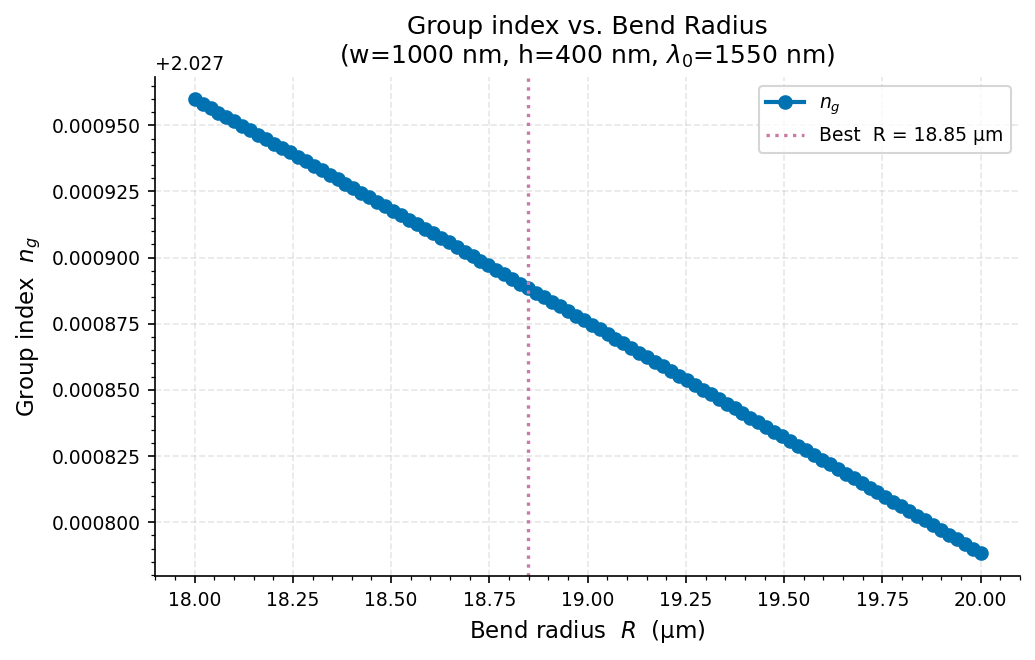

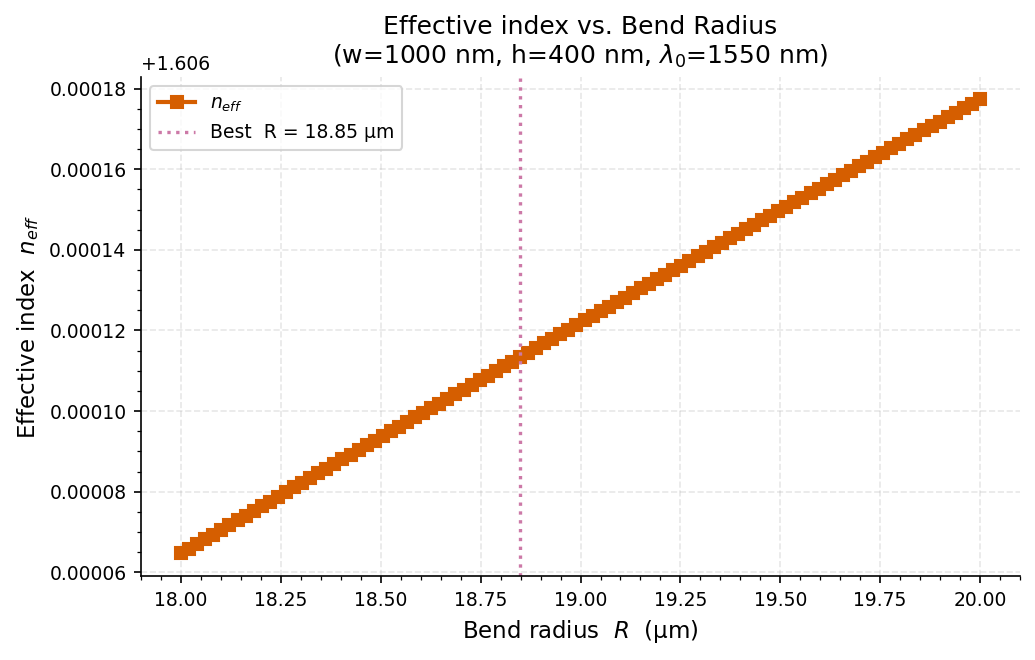

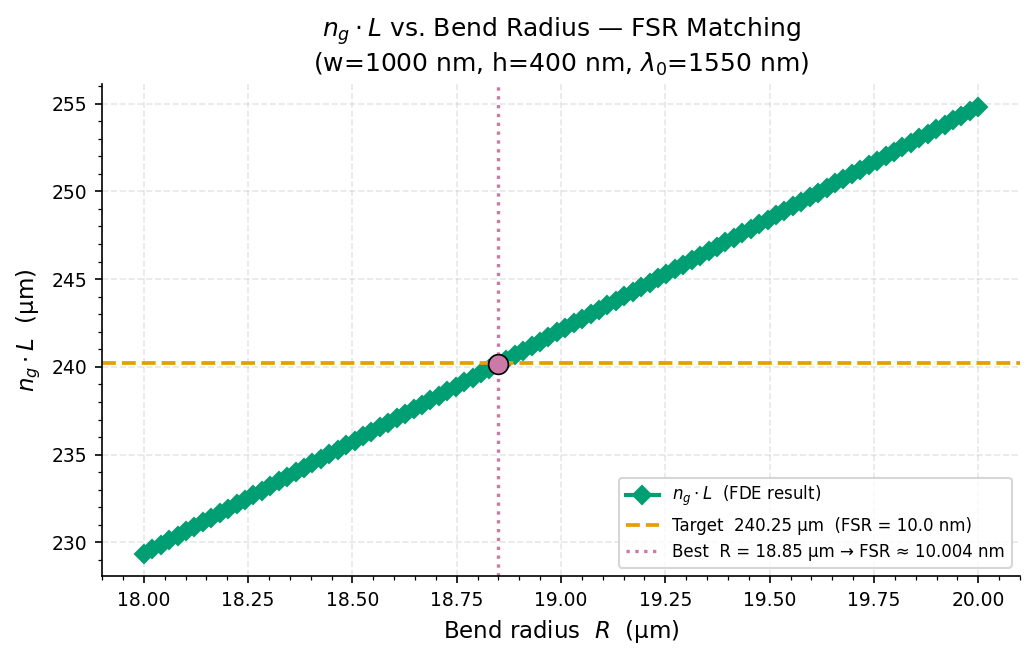


  Cached in : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5
  HDF5 group: ring_radius_sweep/rr_10nm_1550nm_1000nm_18.0-20.0um_100pts

  Variables exported to the next cell:
    rr_best_R_um   = 18.8485   # µm
    rr_best_L_um   = 118.4285   # µm
    rr_best_neff   = 1.606113
    rr_best_ng     = 2.027888
    rr_FSR_pred_nm = 10.0038   # nm


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Ring Resonator Radius Sweep for FSR Matching                     ║
# ║           with HDF5 caching identical to Cells 1-3                         ║
# ║                                                                            ║
# ║  Requires from earlier cells (already in kernel scope):                    ║
# ║    lumapi, np, h5py, log, time, Path, datetime                             ║
# ║    DATA_DIR, HDF5_PATH, VERSION_NAME                                       ║
# ║    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, CORE_THICKNESS_UM         ║
# ║    SIM_Y_SPAN_UM, SIM_Z_BELOW_UM, SIM_Z_ABOVE_UM                          ║
# ║    MESH_CELLS_Y, MESH_CELLS_Z, N_MODES_REQUEST                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# RING DESIGN TARGETS  ← edit only these three lines
# ─────────────────────────────────────────────────────────────────────────────
RR_FSR_NM      = 10.0      # [nm]  target free spectral range
RR_LAM0_NM     = 1550.0    # [nm]  resonance wavelength
RR_WG_WIDTH_NM = 1000.0    # [nm]  waveguide width  (height = CORE_THICKNESS_UM)

# ─────────────────────────────────────────────────────────────────────────────
# RADIUS SWEEP RANGE
# ─────────────────────────────────────────────────────────────────────────────
RR_R_MIN_UM  = 18.0    # [µm]
RR_R_MAX_UM  = 20.0   # [µm]
RR_N_RADII   = 100

# ─────────────────────────────────────────────────────────────────────────────
# ng FINITE-DIFFERENCE STENCIL
#   ng = neff(λ₀) − λ₀ · [neff(λ₀+ΔΛ) − neff(λ₀−ΔΛ)] / (2·ΔΛ)
# ─────────────────────────────────────────────────────────────────────────────
_RR_DELTA_LAM_NM = 5.0   # [nm]  half-span for central difference

# ─────────────────────────────────────────────────────────────────────────────
# HDF5 STORAGE
#   Results are stored as a NEW GROUP inside the existing HDF5 file produced
#   by Cells 1-3 (HDF5_PATH / DATA_DIR already in scope).
#   Group key encodes the sweep parameters so different sweeps never collide.
#
#   Layout inside the existing .h5 file:
#
#   ring_radius_sweep/
#     <group_key>/                    ← one group per unique sweep config
#       metadata/
#         attrs:  fsr_nm, lam0_nm, wg_width_nm, wg_height_nm,
#                 r_min_um, r_max_um, n_radii, delta_lam_nm,
#                 n_SiN, n_SiO2, n_upper_clad,
#                 timestamp_start, timestamp_end
#         datasets: radii_um           [n_radii]
#                   lam_stencil_nm     [3]        (lo, centre, hi)
#       results/
#         neff       [n_radii]   float64  — at λ₀
#         ng         [n_radii]   float64  — central-difference group index
#         te_frac    [n_radii]   float64  — TE polarisation fraction at λ₀
#         ngL_um     [n_radii]   float64  — ng × 2πR  [µm]
#         neff_lo    [n_radii]   float64  — neff at λ₀−ΔΛ  (stencil raw data)
#         neff_hi    [n_radii]   float64  — neff at λ₀+ΔΛ
#       flags/
#         computed   [n_radii]   bool     — True once a radius row is done
# ─────────────────────────────────────────────────────────────────────────────

# ── Group key — uniquely identifies this sweep configuration ─────────────────
# Format:  rr_<fsr>nm_<lam0>nm_<width>nm_<Rmin>-<Rmax>um_<N>pts
# Example: rr_10nm_1550nm_1000nm_2.0-20.0um_19pts
_RR_GROUP_KEY = (
    f"rr_{RR_FSR_NM:.0f}nm_{RR_LAM0_NM:.0f}nm_"
    f"{RR_WG_WIDTH_NM:.0f}nm_"
    f"{RR_R_MIN_UM:.1f}-{RR_R_MAX_UM:.1f}um_{RR_N_RADII}pts"
)
_RR_HDF5_GROUP = f"ring_radius_sweep/{_RR_GROUP_KEY}"

# ─────────────────────────────────────────────────────────────────────────────
# DERIVED CONSTANTS  (do not edit)
# ─────────────────────────────────────────────────────────────────────────────
_lam0_m   = RR_LAM0_NM * 1e-9
_lam_lo_m = (RR_LAM0_NM - _RR_DELTA_LAM_NM) * 1e-9
_lam_hi_m = (RR_LAM0_NM + _RR_DELTA_LAM_NM) * 1e-9
_dlam_m   = 2.0 * _RR_DELTA_LAM_NM * 1e-9

_FSR_m    = RR_FSR_NM * 1e-9
_wg_w_m   = RR_WG_WIDTH_NM * 1e-9
_core_t_um = CORE_THICKNESS_UM

_target_ngL_m  = _lam0_m**2 / _FSR_m
_target_ngL_um = _target_ngL_m * 1e6

# Domain geometry — identical to _init_fde_geometry in Cell 2
_sim_y_span_um  = SIM_Y_SPAN_UM
_sim_z_below_um = SIM_Z_BELOW_UM
_sim_z_above_um = SIM_Z_ABOVE_UM
_sim_z_span_um  = _sim_z_below_um + _core_t_um + _sim_z_above_um
_half_t_um      = _core_t_um / 2.0
_sio2_z_ctr_um  = -(_half_t_um + _sim_z_below_um / 2.0)
_sio2_z_span_um = _sim_z_below_um
_sim_z_ctr_um   = (_sim_z_above_um - _sim_z_below_um) / 2.0

_radii_um = np.linspace(RR_R_MIN_UM, RR_R_MAX_UM, RR_N_RADII)
_radii_m  = _radii_um * 1e-6
_N        = RR_N_RADII

print("=" * 65)
print("  Ring Resonator — Radius Sweep for FSR Matching")
print("=" * 65)
print(f"  Target FSR           : {RR_FSR_NM:.2f} nm")
print(f"  Resonance wavelength : {RR_LAM0_NM:.1f} nm")
print(f"  Waveguide width      : {RR_WG_WIDTH_NM:.0f} nm")
print(f"  Waveguide height     : {_core_t_um*1e3:.0f} nm")
print(f"  n_core               : {N_SIN_FIXED}   (N_SIN_FIXED)")
print(f"  n_lower_clad         : {N_SIO2_FIXED}  (N_SIO2_FIXED)")
print(f"  n_upper_clad         : {N_UPPER_CLADDING}   (N_UPPER_CLADDING)")
print(f"  Required ng·L        : {_target_ngL_um:.4f} µm")
print(f"  ng stencil           : ±{_RR_DELTA_LAM_NM:.1f} nm  ({_N*3} FDE solves if uncached)")
print(f"  Radius sweep         : {RR_R_MIN_UM:.1f} – {RR_R_MAX_UM:.1f} µm  ({_N} pts)")
print(f"  HDF5 group           : {_RR_HDF5_GROUP}")
print(f"  HDF5 file            : {HDF5_PATH}")
print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# HDF5 HELPER — initialise the group for this sweep inside the existing file
# ─────────────────────────────────────────────────────────────────────────────
def _rr_init_hdf5(hf) -> None:
    """
    Create ring_radius_sweep/<group_key>/ inside an already-open h5py file
    opened in 'r+' or 'a' mode.  Pre-allocates all datasets with NaN / False.
    Mirrors the structure of _init_hdf5 from Cell 2 exactly.
    """
    g = hf.require_group(_RR_HDF5_GROUP)

    # ── metadata ─────────────────────────────────────────────────────────────
    mg = g.require_group("metadata")
    mg.attrs["fsr_nm"]         = RR_FSR_NM
    mg.attrs["lam0_nm"]        = RR_LAM0_NM
    mg.attrs["wg_width_nm"]    = RR_WG_WIDTH_NM
    mg.attrs["wg_height_nm"]   = _core_t_um * 1e3
    mg.attrs["r_min_um"]       = RR_R_MIN_UM
    mg.attrs["r_max_um"]       = RR_R_MAX_UM
    mg.attrs["n_radii"]        = _N
    mg.attrs["delta_lam_nm"]   = _RR_DELTA_LAM_NM
    mg.attrs["n_SiN"]          = N_SIN_FIXED
    mg.attrs["n_SiO2"]         = N_SIO2_FIXED
    mg.attrs["n_upper_clad"]   = N_UPPER_CLADDING
    mg.attrs["version_name"]   = VERSION_NAME
    mg.attrs["timestamp_start"] = datetime.now().isoformat()

    # axis coordinate arrays
    if "radii_um" not in mg:
        mg.create_dataset("radii_um",       data=_radii_um)
    if "lam_stencil_nm" not in mg:
        mg.create_dataset("lam_stencil_nm",
                          data=np.array([RR_LAM0_NM - _RR_DELTA_LAM_NM,
                                         RR_LAM0_NM,
                                         RR_LAM0_NM + _RR_DELTA_LAM_NM]))

    # ── results — NaN-initialised, chunked per radius row ────────────────────
    rg = g.require_group("results")
    _nan = np.full(_N, np.nan, dtype=np.float64)
    for ds_name in ("neff", "ng", "te_frac", "ngL_um", "neff_lo", "neff_hi"):
        if ds_name not in rg:
            rg.create_dataset(ds_name, data=_nan.copy(), chunks=(_N,))

    # ── progress flag ─────────────────────────────────────────────────────────
    fg = g.require_group("flags")
    if "computed" not in fg:
        fg.create_dataset("computed",
                          data=np.zeros(_N, dtype=bool),
                          chunks=(_N,))


# ─────────────────────────────────────────────────────────────────────────────
# HDF5 HELPER — load existing cache into memory arrays
# ─────────────────────────────────────────────────────────────────────────────
def _rr_load_cache(hf,
                   neff_arr, ng_arr, te_arr,
                   ngL_arr, neff_lo_arr, neff_hi_arr,
                   computed) -> int:
    """
    Read ring_radius_sweep/<group_key>/ from an open h5py file into the
    pre-allocated in-memory arrays.  Returns number of cached points.
    All arrays are modified in-place.
    """
    g  = hf[_RR_HDF5_GROUP]
    rg = g["results"]
    fg = g["flags"]

    neff_arr[:]    = rg["neff"][:]
    ng_arr[:]      = rg["ng"][:]
    te_arr[:]      = rg["te_frac"][:]
    ngL_arr[:]     = rg["ngL_um"][:] * 1e-6   # stored in µm, keep in m here
    neff_lo_arr[:] = rg["neff_lo"][:]
    neff_hi_arr[:] = rg["neff_hi"][:]
    computed[:]    = fg["computed"][:]

    return int(computed.sum())


# ─────────────────────────────────────────────────────────────────────────────
# FDE HELPERS  (unchanged from working version)
# ─────────────────────────────────────────────────────────────────────────────
def _rr_build_fde(mode, radius_m: float, wavelength_m: float) -> None:
    """Build bent waveguide cross-section + FDE solver for one (R, λ) point."""
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     _sim_z_ctr_um  * 1e-6)
    m.set("y span",                _sim_y_span_um * 1e-6)
    m.set("z span",                _sim_z_span_um * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", N_MODES_REQUEST)
    m.set("mesh cells y",          MESH_CELLS_Y)
    m.set("mesh cells z",          MESH_CELLS_Z)
    m.set("bent waveguide",        1)
    m.set("bend radius",           radius_m)
    m.set("bend orientation",      90)

    m.addrect()
    m.set("name",    "RR_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", _sim_y_span_um * 1e-6)
    m.set("z",       _sim_z_ctr_um  * 1e-6)
    m.set("z span",  _sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_UPPER_CLADDING)

    m.addrect()
    m.set("name",    "RR_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", _sim_y_span_um  * 1e-6)
    m.set("z",       _sio2_z_ctr_um * 1e-6)
    m.set("z span",  _sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)

    m.addrect()
    m.set("name",    "RR_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", _wg_w_m)
    m.set("z",       0.0);  m.set("z span", _core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)


def _rr_solve_neff(mode, radius_m: float, wavelength_m: float):
    """Single FDE solve → (Re(neff), TE fraction) for mode 1."""
    _rr_build_fde(mode, radius_m, wavelength_m)
    mode.run()
    mode.findmodes()
    raw_neff = mode.getdata("FDE::data::mode1", "neff")
    raw_te   = mode.getdata("FDE::data::mode1", "TE polarization fraction")
    neff_c   = complex(np.asarray(raw_neff).flat[0])
    te_v     = float(np.asarray(raw_te).flat[0])
    return neff_c.real, te_v


def _rr_neff_ng(mode, radius_m: float):
    """
    Three-point central-difference ng at lam0 for a given bend radius.
    Returns (neff_at_lam0, ng, te_frac, neff_lo, neff_hi).
    """
    neff_lo, _    = _rr_solve_neff(mode, radius_m, _lam_lo_m)
    neff_0,  te_v = _rr_solve_neff(mode, radius_m, _lam0_m)
    neff_hi, _    = _rr_solve_neff(mode, radius_m, _lam_hi_m)
    dneff_dlam    = (neff_hi - neff_lo) / _dlam_m
    ng            = neff_0 - _lam0_m * dneff_dlam
    return neff_0, ng, te_v, neff_lo, neff_hi


# ─────────────────────────────────────────────────────────────────────────────
# IN-MEMORY ARRAYS  (NaN-initialised; overwritten by cache or FDE)
# ─────────────────────────────────────────────────────────────────────────────
_neff_arr    = np.full(_N, np.nan)
_ng_arr      = np.full(_N, np.nan)
_te_arr      = np.full(_N, np.nan)
_ngL_arr     = np.full(_N, np.nan)   # [m]
_neff_lo_arr = np.full(_N, np.nan)
_neff_hi_arr = np.full(_N, np.nan)
_computed    = np.zeros(_N, dtype=bool)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — HDF5 CACHE CHECK
#   Open the existing file in append mode ('a').
#   If our group is already there, load what is cached.
#   If the group is missing, create it now.
#   Either way the file stays open for the sweep loop below.
# ─────────────────────────────────────────────────────────────────────────────
_hf = h5py.File(HDF5_PATH, "a")   # 'a' = read/write, create if missing

if _RR_HDF5_GROUP in _hf:
    log.info(f"Ring sweep cache found → {_RR_HDF5_GROUP}")
    _n_cached = _rr_load_cache(
        _hf,
        _neff_arr, _ng_arr, _te_arr,
        _ngL_arr, _neff_lo_arr, _neff_hi_arr,
        _computed,
    )
    _remaining = _N - _n_cached
    log.info(f"Cached: {_n_cached}/{_N}  |  Remaining: {_remaining}")
    if _remaining == 0:
        log.info("All radii already computed — skipping FDE entirely.")
else:
    log.info(f"No ring sweep cache found — initialising group: {_RR_HDF5_GROUP}")
    _rr_init_hdf5(_hf)
    _hf.flush()
    _n_cached  = 0
    _remaining = _N


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — FDE SWEEP  (skipped entirely when all radii are cached)
# ─────────────────────────────────────────────────────────────────────────────
_hdr = (f"{'Radius (µm)':>12}  {'neff':>10}  {'ng':>10}  "
        f"{'TE frac':>8}  {'ng·L (µm)':>12}  {'Δ/target':>10}  {'source':>8}")
print(f"\n{_hdr}")
print("-" * len(_hdr))

# Print already-cached rows first so the table is complete
for _i in range(_N):
    if _computed[_i]:
        _ngL_m = _ngL_arr[_i]
        _delta  = (_ngL_m - _target_ngL_m) / _target_ngL_m * 100.0
        print(f"  {_radii_um[_i]:>10.2f}  {_neff_arr[_i]:>10.4f}  "
              f"{_ng_arr[_i]:>10.4f}  {_te_arr[_i]:>8.3f}  "
              f"{_ngL_m*1e6:>12.4f}  {_delta:>+9.2f}%  {'cache':>8}")

if _remaining > 0:
    _runs_done = 0
    _t0 = time.time()
    log.info(f"Launching MODE session  ({_remaining} radii to compute) …")
    _rr_mode = lumapi.MODE(hide=False)

    try:
        for _i, (_R_um, _R_m) in enumerate(zip(_radii_um, _radii_m)):
            if _computed[_i]:
                continue   # already in cache — skip

            try:
                _neff_v, _ng_v, _te_v, _nlo, _nhi = _rr_neff_ng(_rr_mode, _R_m)
            except Exception as _exc:
                log.warning(f"  R = {_R_um:6.2f} µm  FAILED: {_exc}")
                # Mark as done with NaN so a re-run doesn't retry a broken radius
                _computed[_i] = True
                _hf[f"{_RR_HDF5_GROUP}/flags/computed"][_i] = True
                _hf.flush()
                continue

            _L_m   = 2.0 * np.pi * _R_m
            _ngL_m = _ng_v * _L_m

            # ── store in memory ───────────────────────────────────────────────
            _neff_arr[_i]    = _neff_v
            _ng_arr[_i]      = _ng_v
            _te_arr[_i]      = _te_v
            _ngL_arr[_i]     = _ngL_m
            _neff_lo_arr[_i] = _nlo
            _neff_hi_arr[_i] = _nhi
            _computed[_i]    = True

            # ── write to HDF5 immediately + flush (fault-safe) ────────────────
            _rg = _hf[f"{_RR_HDF5_GROUP}/results"]
            _rg["neff"]   [_i] = _neff_v
            _rg["ng"]     [_i] = _ng_v
            _rg["te_frac"][_i] = _te_v
            _rg["ngL_um"] [_i] = _ngL_m * 1e6        # stored in µm
            _rg["neff_lo"][_i] = _nlo
            _rg["neff_hi"][_i] = _nhi
            _hf[f"{_RR_HDF5_GROUP}/flags/computed"][_i] = True
            _hf.flush()

            _runs_done += 1
            _delta = (_ngL_m - _target_ngL_m) / _target_ngL_m * 100.0
            print(f"  {_R_um:>10.2f}  {_neff_v:>10.4f}  {_ng_v:>10.4f}  "
                  f"{_te_v:>8.3f}  {_ngL_m*1e6:>12.4f}  {_delta:>+9.2f}%  "
                  f"{'FDE':>8}")

            # progress every 5 new solves
            if _runs_done % 5 == 0 or _runs_done == _remaining:
                _elapsed = time.time() - _t0
                _rate    = _runs_done / _elapsed if _elapsed > 0 else 1e-9
                _eta     = (_remaining - _runs_done) / _rate
                log.info(f"  [{_runs_done:3d}/{_remaining}]  "
                         f"R = {_R_um:.1f} µm  |  "
                         f"{_rate:.2f} radii/s  |  ETA {_eta:.0f} s")

    finally:
        _rr_mode.close()
        _elapsed_total = time.time() - _t0
        log.info(f"MODE session closed  "
                 f"({_runs_done} new solves in {_elapsed_total:.1f} s, "
                 f"avg {_elapsed_total/max(_runs_done*3,1):.2f} s/FDE)")

# ── close-out metadata ────────────────────────────────────────────────────────
_hf[_RR_HDF5_GROUP]["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
_hf[_RR_HDF5_GROUP]["metadata"].attrs["runs_completed"] = int(_computed.sum())
_hf.flush()
_hf.close()
log.info(f"HDF5 closed  →  {HDF5_PATH}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — FIND BEST MATCH  (uses in-memory arrays, already complete)
# ─────────────────────────────────────────────────────────────────────────────
_valid = ~np.isnan(_ng_arr)

if not np.any(_valid):
    raise RuntimeError(
        "All radius sweep FDE runs failed.  "
        "Check the WARNING lines above for the specific error."
    )

_R_v    = _radii_um[_valid]
_neff_v = _neff_arr[_valid]
_ng_v   = _ng_arr[_valid]
_te_v   = _te_arr[_valid]
_ngL_v  = _ngL_arr[_valid]   # [m]

_dist = np.abs(_ngL_v - _target_ngL_m)
_bi   = int(np.argmin(_dist))

# ── exported to downstream cells ─────────────────────────────────────────────
rr_best_R_um   = _R_v[_bi]
rr_best_L_um   = 2.0 * np.pi * rr_best_R_um
rr_best_neff   = _neff_v[_bi]
rr_best_ng     = _ng_v[_bi]
rr_best_ngL_um = _ngL_v[_bi] * 1e6
rr_FSR_pred_nm = (_lam0_m**2 / _ngL_v[_bi]) * 1e9

print("\n" + "=" * 65)
print("  BEST MATCH")
print("=" * 65)
print(f"  Bend radius  R = {rr_best_R_um:.4f} µm")
print(f"  Ring length  L = {rr_best_L_um:.4f} µm  (= 2π × R)")
print(f"  neff           = {rr_best_neff:.6f}")
print(f"  ng             = {rr_best_ng:.6f}")
print(f"  ng·L achieved  = {rr_best_ngL_um:.4f} µm")
print(f"  ng·L target    = {_target_ngL_um:.4f} µm")
print(f"  Residual       = {_dist[_bi]*1e6:.5f} µm  "
      f"({_dist[_bi]/_target_ngL_m*100:.3f} %)")
print(f"  FSR predicted  = {rr_FSR_pred_nm:.4f} nm  (target {RR_FSR_NM:.2f} nm)")
print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — PLOTS
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "lines.linewidth":   2.0,
    "lines.markersize":  6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
})

_C_NG   = "#0072B2"
_C_NEFF = "#D55E00"
_C_NGL  = "#009E73"
_C_BEST = "#CC79A7"
_C_TGT  = "#E69F00"

_suffix = (f"w={RR_WG_WIDTH_NM:.0f} nm, h={_core_t_um*1e3:.0f} nm, "
           f"$\\lambda_0$={RR_LAM0_NM:.0f} nm")

# ── Figure 1 — ng vs radius ──────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(_R_v, _ng_v, "o-", color=_C_NG, label="$n_g$")
ax1.axvline(rr_best_R_um, color=_C_BEST, ls=":", lw=1.6,
            label=f"Best  R = {rr_best_R_um:.2f} µm")
ax1.set_xlabel("Bend radius  $R$  (µm)")
ax1.set_ylabel("Group index  $n_g$")
ax1.set_title(f"Group index vs. Bend Radius\n({_suffix})")
ax1.legend()
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig1.tight_layout();  plt.show()

# ── Figure 2 — neff vs radius ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
ax2.plot(_R_v, _neff_v, "s-", color=_C_NEFF, label="$n_{eff}$")
ax2.axvline(rr_best_R_um, color=_C_BEST, ls=":", lw=1.6,
            label=f"Best  R = {rr_best_R_um:.2f} µm")
ax2.set_xlabel("Bend radius  $R$  (µm)")
ax2.set_ylabel("Effective index  $n_{eff}$")
ax2.set_title(f"Effective index vs. Bend Radius\n({_suffix})")
ax2.legend()
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig2.tight_layout();  plt.show()

# ── Figure 3 — ng·L vs radius with target line ───────────────────────────────
fig3, ax3 = plt.subplots(figsize=(7, 4.5))
ax3.plot(_R_v, _ngL_v * 1e6, "D-", color=_C_NGL,
         label="$n_g \\cdot L$  (FDE result)")
ax3.axhline(_target_ngL_um, color=_C_TGT, ls="--", lw=1.8,
            label=f"Target  {_target_ngL_um:.2f} µm  (FSR = {RR_FSR_NM:.1f} nm)")
ax3.axvline(rr_best_R_um, color=_C_BEST, ls=":", lw=1.6,
            label=f"Best  R = {rr_best_R_um:.2f} µm → FSR ≈ {rr_FSR_pred_nm:.3f} nm")
ax3.scatter([rr_best_R_um], [rr_best_ngL_um],
            s=90, zorder=5, color=_C_BEST, edgecolors="k", linewidths=0.8)
ax3.set_xlabel("Bend radius  $R$  (µm)")
ax3.set_ylabel("$n_g \\cdot L$  (µm)")
ax3.set_title(f"$n_g \\cdot L$ vs. Bend Radius — FSR Matching\n({_suffix})")
ax3.legend(fontsize=8)
ax3.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig3.tight_layout();  plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n  Cached in : {HDF5_PATH}")
print(f"  HDF5 group: {_RR_HDF5_GROUP}")
print(f"\n  Variables exported to the next cell:")
print(f"    rr_best_R_um   = {rr_best_R_um:.4f}   # µm")
print(f"    rr_best_L_um   = {rr_best_L_um:.4f}   # µm")
print(f"    rr_best_neff   = {rr_best_neff:.6f}")
print(f"    rr_best_ng     = {rr_best_ng:.6f}")
print(f"    rr_FSR_pred_nm = {rr_FSR_pred_nm:.4f}   # nm")